In [7]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import corner
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Get the current working directory
current_path = os.getcwd()
two_levels_up = os.path.dirname(os.path.dirname(os.getcwd()))
parent_directory = two_levels_up#os.path.abspath(os.path.join(current_path, os.pardir))
print("Parent Directory:", parent_directory)
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))
sys.path.append(os.path.dirname(os.getcwd()))

from class_analysis import metrics_creator
from class_analysis import create_df_to_plot
# from ssh_connect import ssh_che
from connect_CHE import download_data
from read_save import read_data
from class_analysis import graph_maker_1plot
from matplotlib.colors import LogNorm
from scipy.stats import chi2
from astropy import constants as C
from astropy import units as u
from ulens_params import event_param, microlensing_params
from detection_criteria import mag
import rubin_sim
import rubin_sim.maf as maf
from rubin_sim.data import get_baseline
from plot_hist import *
import pyarrow.dataset as ds
from filter_df import prepare_and_compute_metrics

Parent Directory: /home/anibal/microlensing/simulation_Rubin/roman_rubin


In [8]:
labelsparams = lambda p: labels[p]
label_m1 = lambda p: f'$\\alpha({labels[p]})$'
label_m3 = lambda p :f'$\\gamma({labels[p]})$'
label_m2 = lambda p :f'$\\beta({labels[p]})$'

label_dict={'piE':r"$\pi_E$",
            'tE':r"$t_E$",
            'rho':r"$\rho$",
            'piEE':r'$\pi_{EE}$',
            'piEN':r'$\pi_{EN}$'}
CLR = ['k','blue','r','orange','purple','green']
label_met = ['met1','met2','met3']
label_rmet_lat = [r"$\frac{|\pi_E - \hat{\pi}_E|_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|_{Roman}}$", r"$\frac{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman}}$", 
                 r"$\frac{\sigma_{\pi_E}/\hat{\pi}_E(Roman+Rubin)}{\sigma_{\pi_E}/\hat{\pi}_E(Roman)}$"]
label_rmet_lat = [r"$\frac{RB(\pi_E)_{Roman+Rubin}}{RB(\pi_E)_{Roman}}$", r"$\frac{SB(\pi_E)_{Roman+Rubin}}{SB(\pi_E)_{Roman}}$", 
                 r"$\frac{NU(\pi_E)_{Roman+Rubin}}{NU(\pi_E)_{Roman}}$"]
param_names = ['u0', 'tE', 'piE','piEE','piEN']
param_labels = [r'$\log_{10}(u_0)$', r'$t_E [day]$', r'$\log_{10}(\pi_E)$', r'$\log_{10}(|\pi_{EE}|)$',r'$\log_{10}(|\pi_{EN}|)$']

dict_cat_peak = {"A":"peak in Rubin+Roman",
                "B":"peak in Rubin",
                "C":"peak in Roman"}

In [9]:
model = 'FSPL'
system_type = "FFP"
# 
# model = 'PSPL'
# system_type = "BH"

In [10]:
if model=="PSPL":
    params = ["tE", "piE", "piEE", "piEN"]
elif model=="FSPL":
    params = ["tE", "piE","rho", "piEE", "piEN"]

true = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/true_{system_type}.parquet")
fit_rr = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/fit_rr_{system_type}.parquet")
fit_roman = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/fit_roman_{system_type}.parquet")
data = "rr"
met_1_rr = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/met_1_{data}_{system_type}.parquet")
met_2_rr = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/met_2_{data}_{system_type}.parquet")
met_3_rr = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/met_3_{data}_{system_type}.parquet")

data = "roman"
met_1_roman = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/met_1_{data}_{system_type}.parquet")
met_2_roman = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/met_2_{data}_{system_type}.parquet")
met_3_roman = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/met_3_{data}_{system_type}.parquet")

del data

met1_ratio = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/met1_ratio_{system_type}.parquet")
met2_ratio = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/met2_ratio_{system_type}.parquet")
met3_ratio = pd.read_parquet(parent_directory+f"/all_results/{system_type}_metrics/met3_ratio_{system_type}.parquet")



In [19]:
print(len(true))
print(len(true[true["rho"]>10*true["u0"]])/len(true),len(true[true["rho"]<10*true["u0"]])/len(true))

63909
0.5044829366755856 0.4955170633244144


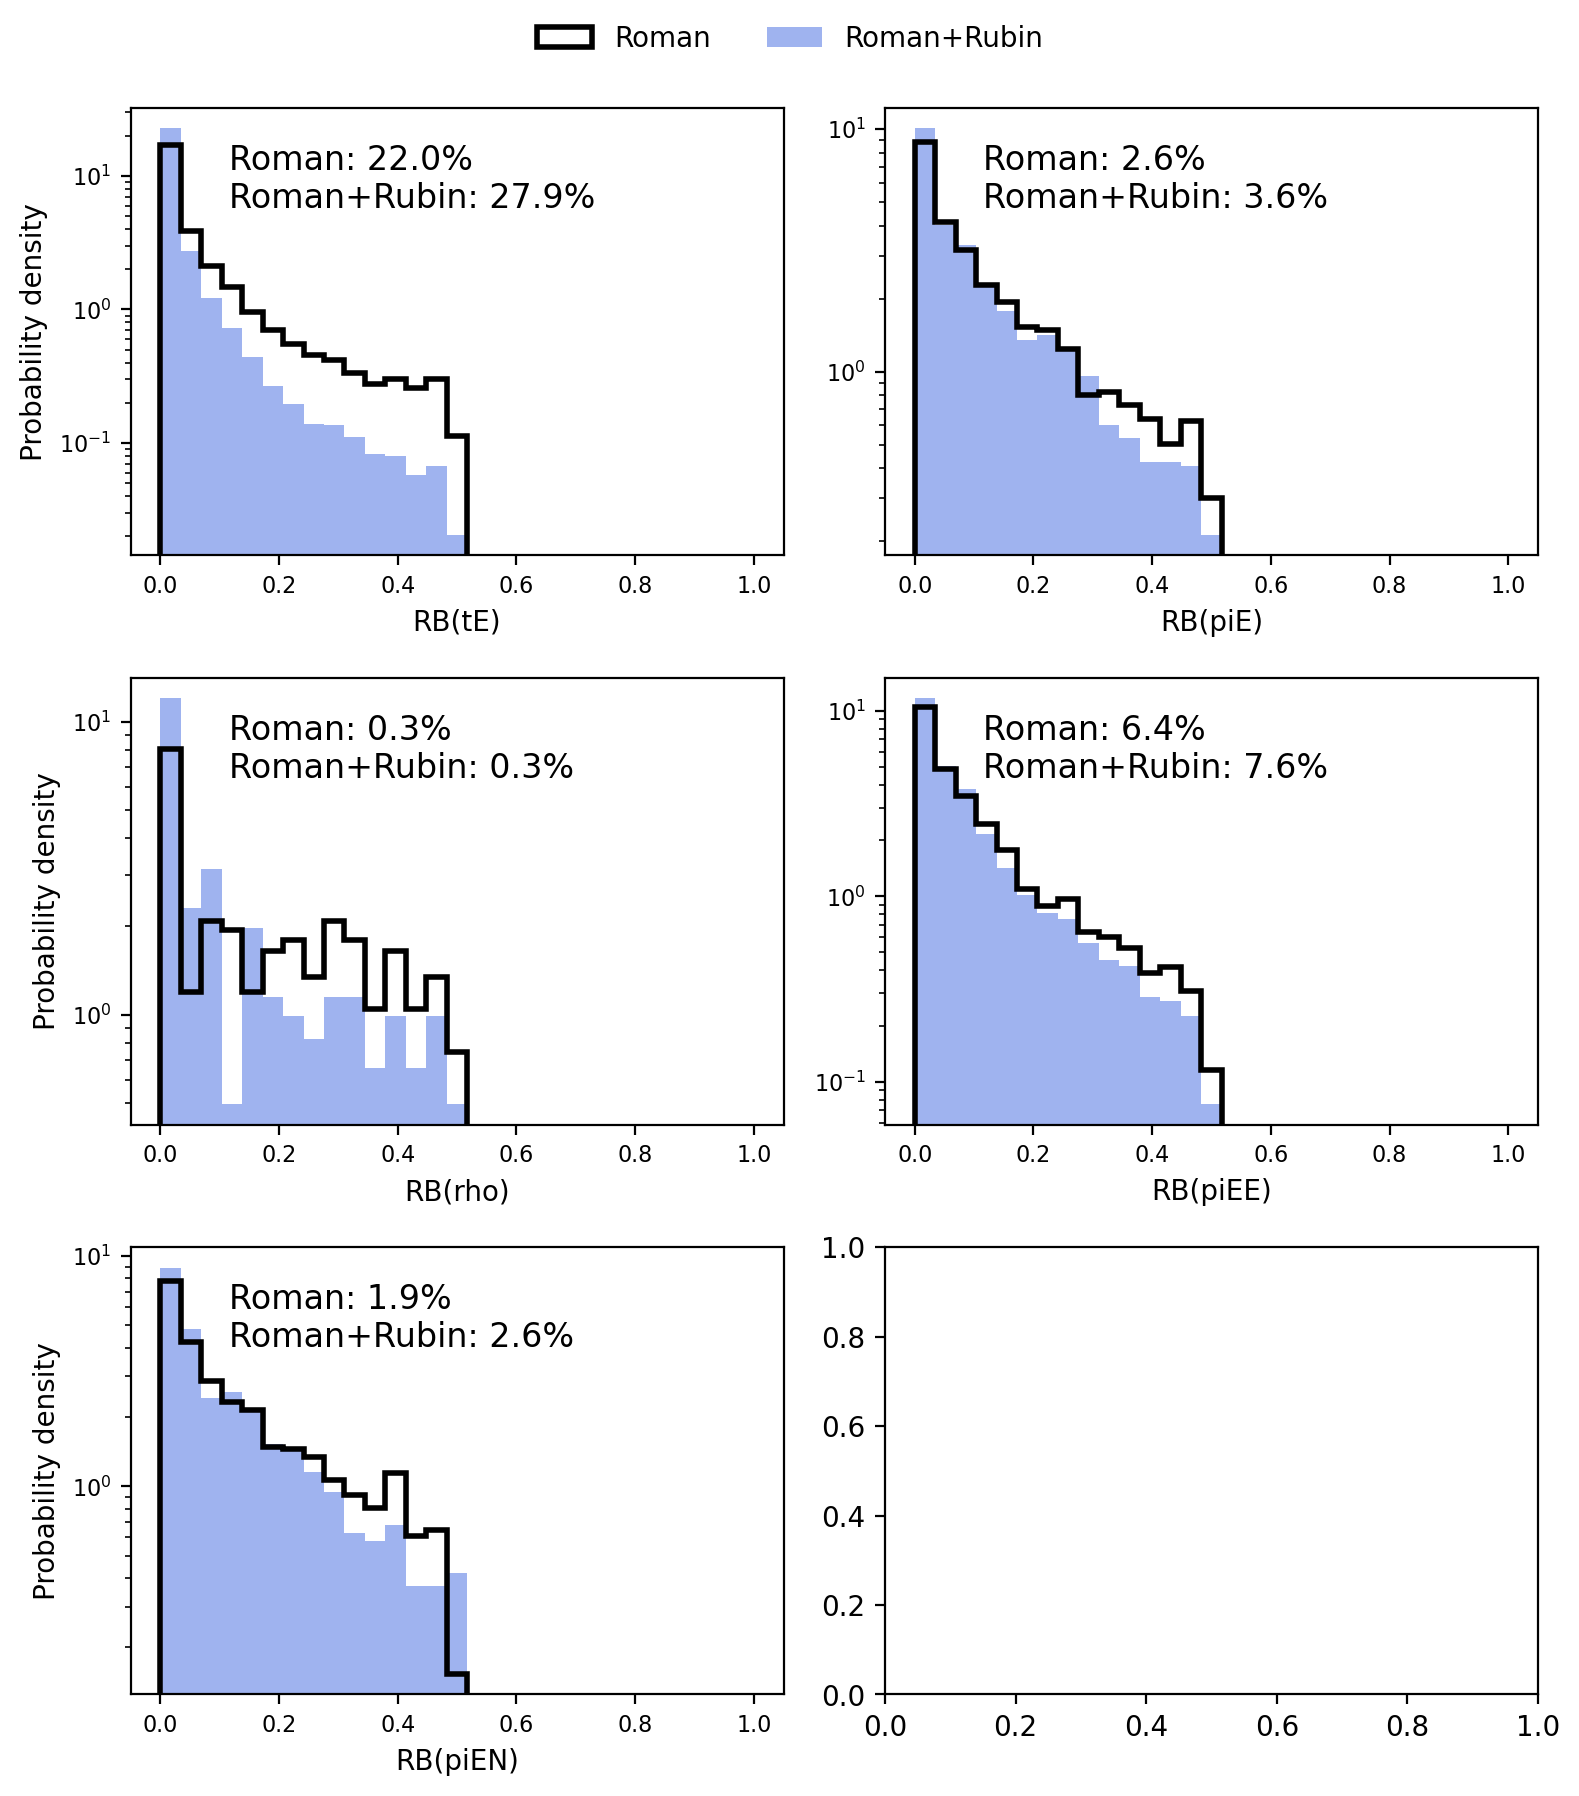

In [5]:

fig, axes = plt.subplots(3, 2, figsize=(8, 9), dpi=200)
axes = axes.flatten()
rb_edge = 0.5
bins= np.linspace(0,1,30)
for ax, p in zip(axes, params):

    # --- merges igual que antes ---
    df_rom = met_1_roman[["Set", "Source", p]].rename(columns={p: "RB"})
    df_rom = df_rom.merge(
        met_3_roman[["Set", "Source", p]].rename(columns={p: "NU"}),
        on=["Set", "Source"], how="inner"
    )

    df_rr = met_1_rr[["Set", "Source", p]].rename(columns={p: "RB"})
    df_rr = df_rr.merge(
        met_3_rr[["Set", "Source", p]].rename(columns={p: "NU"}),
        on=["Set", "Source"], how="inner"
    )

    df_rom = df_rom[(df_rom["NU"] < 0.5) & (df_rom["RB"] < rb_edge)]
    df_rr  = df_rr[(df_rr["NU"]  < 0.5) & (df_rr["RB"]  < rb_edge)]

    frac_rom = len(df_rom) / len(met_1_roman)
    frac_rr  = len(df_rr)  / len(met_1_rr)

    ax.hist(df_rom["RB"], bins=bins, density=True,
            color="royalblue", alpha=0.5)

    ax.hist(df_rr["RB"], bins=bins, density=True,
            histtype="step", linewidth=2, color="k")

    # fracciones dentro del panel
    ax.text(0.15, 0.92,
            f"Roman: {frac_rom:.1%}\nRoman+Rubin: {frac_rr:.1%}",
            transform=ax.transAxes, fontsize=12, va="top")

    ax.set_yscale("log")
    # ax.set_title(p, fontsize=10)
    ax.tick_params(labelsize=8)

# etiquetas comunes
# for ax in axes[4:]:
    ax.set_xlabel(f"RB({p})", fontsize=10)
for ax in axes[::2]:
    ax.set_ylabel("Probability density", fontsize=10)

# leyenda global
fig.legend(["Roman", "Roman+Rubin"],
           loc="upper center", ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


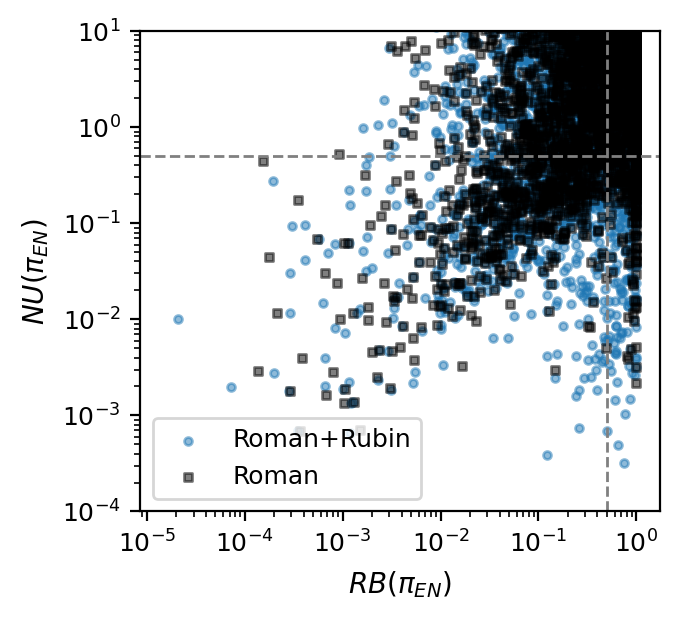

In [6]:
plt.close("all")
fig, ax = plt.subplots(figsize=(3.5, 3.2),dpi=200)  # ancho columna journal

# --- Roman+Rubin ---
ax.scatter(met_1_rr['piEN'], met_3_rr['piEN'],
           s=8, alpha=0.5, marker='o',
           color='tab:blue', label='Roman+Rubin')

# --- Roman ---
ax.scatter(met_1_roman['piEN'], met_3_roman['piEN'],
           s=8, alpha=0.5, marker='s',
           color='black', label='Roman')

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$RB(\pi_{EN})$", fontsize=10)
ax.set_ylabel(r"$NU(\pi_{EN})$", fontsize=10)

# Líneas guía más sutiles
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)

ax.set_ylim(1e-4, 1e1)

ax.tick_params(labelsize=9)

ax.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()


(array([ 9.,  8.,  7., 10., 12.,  5., 14., 10., 14., 11.]),
 array([ 0.14554144,  2.12883809,  4.11213474,  6.0954314 ,  8.07872805,
        10.0620247 , 12.04532135, 14.028618  , 16.01191466, 17.99521131,
        19.97850796]),
 <BarContainer object of 10 artists>)

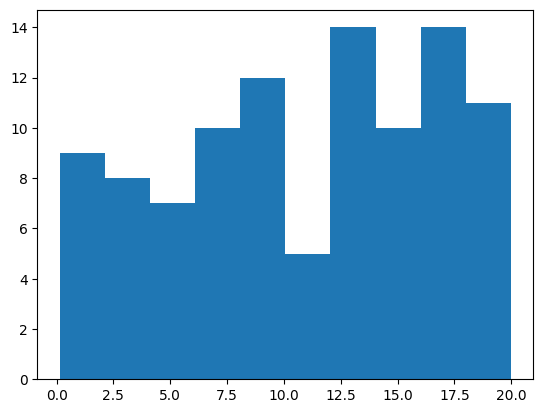

In [112]:
plt.hist(np.random.uniform(3.146351865506143e-05,20,100))


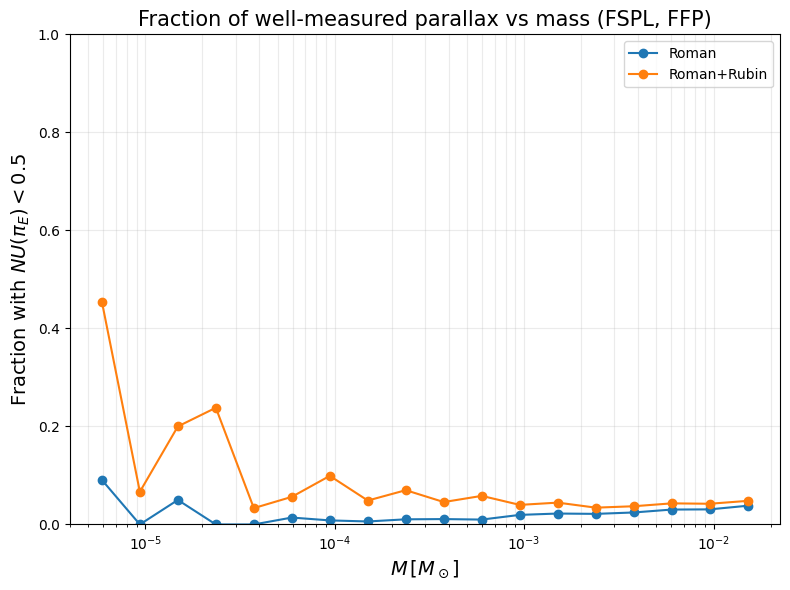

In [190]:


cols_id = ["Source", "Set"]

# ============================================================
# Merge
# ============================================================
df = true[cols_id + ["mass"]].merge(
    met_3_roman[cols_id + ["piE"]],
    on=cols_id,
    how="inner"
)

df = df.rename(columns={"piE": "NU_roman"})

df = df.merge(
    met_3_rr[cols_id + ["piE"]],
    on=cols_id,
    how="inner"
)

df = df.rename(columns={"piE": "NU_rr"})

# ============================================================
# Filtros
# ============================================================
mask = (
    np.isfinite(df["mass"]) &
    np.isfinite(df["NU_roman"]) &
    np.isfinite(df["NU_rr"]) &
    (df["mass"] > 0) &
    (df["NU_roman"] > 0) &
    (df["NU_rr"] > 0)
)

df = df[mask].copy()

# ============================================================
# Binning en masa
# ============================================================
n_bins = 20

mass_bins = np.logspace(
    np.log10(df["mass"].min()),
    np.log10(df["mass"].max()),
    n_bins + 1
)

mass_centers = np.sqrt(mass_bins[:-1] * mass_bins[1:])

# ============================================================
# Calcular fracciones
# ============================================================
f_roman = []
f_rr = []
counts = []

threshold = 0.5

for i in range(len(mass_bins) - 1):
    m1 = mass_bins[i]
    m2 = mass_bins[i + 1]

    in_bin = (df["mass"] >= m1) & (df["mass"] < m2)

    N = in_bin.sum()
    counts.append(N)

    if N > 0:
        N_good_roman = (df.loc[in_bin, "NU_roman"] < threshold).sum()
        N_good_rr = (df.loc[in_bin, "NU_rr"] < threshold).sum()

        f_roman.append(N_good_roman / N)
        f_rr.append(N_good_rr / N)
    else:
        f_roman.append(np.nan)
        f_rr.append(np.nan)

f_roman = np.array(f_roman)
f_rr = np.array(f_rr)
counts = np.array(counts)

# ============================================================
# Filtrar bins con poca estadística
# ============================================================
min_events = 10
valid = counts >= min_events

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    mass_centers[valid],
    f_roman[valid],
    marker="o",
    linestyle="-",
    label="Roman"
)

ax.plot(
    mass_centers[valid],
    f_rr[valid],
    marker="o",
    linestyle="-",
    label="Roman+Rubin"
)

ax.set_xscale("log")

ax.set_xlabel(r"$M\,[M_\odot]$", fontsize=14)
ax.set_ylabel(r"Fraction with $NU(\pi_E) < 0.5$", fontsize=14)

ax.set_title(
    rf"Fraction of well-measured parallax vs mass ({model}, {system_type})",
    fontsize=15
)

ax.set_ylim(0, 1)

ax.grid(True, which="both", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()



In [191]:
1*u.M_sun.to("M_jup")

1047.5655146604772

In [126]:
true[true["mass"]<2*u.M_earth.to("M_sun")]

,Source,Set,t0,u0,tE,rho,piEN,piEE,Category,mass,...,y_rpeak,u,u_peak,u_npeak,u_lpeak,u_rpeak,peak_flag,flag_relevance,total_npeak,flag_total_npeak_gt10
531,12831,1,2.461828e+06,-1.261565,0.102361,0.163773,-56.663298,-62.609401,None,0.000002,...,0.0,NaN,0.0,0.0,NaN,NaN,C,True,6.0,0
17896,12831,2,2.461828e+06,-1.261565,0.165214,0.259050,-57.074657,-63.063927,None,0.000002,...,0.0,NaN,0.0,0.0,NaN,NaN,C,True,10.0,0
52783,12831,4,2.461828e+06,-1.261565,0.094223,0.163854,-45.521812,-50.298755,None,0.000002,...,NaN,NaN,0.0,0.0,NaN,NaN,C,True,5.0,0


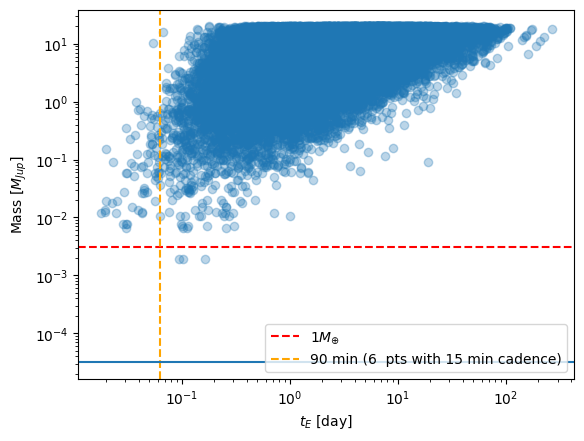

In [164]:
binesx = np.logspace(-7,-1,20)
binesy = np.logspace(-2,1,20)
plt.scatter(true["tE"],true["mass"]*1047.56,alpha=0.3)#,bins=(binesx,binesy))
plt.ylabel(r"Mass $ [M_{Jup}] $")
plt.xlabel("$t_E$ [day] ")
plt.axhline(float(1*u.M_earth.to("M_jup")),color="red",linestyle="--",label=r"$1 M_{\oplus}$")
plt.axvline(1.5/24,color="orange", linestyle="dashed",label="90 min (6  pts with 15 min cadence)")
# plt.axvline(0.75/24,color="orange", linestyle="dashed",label=" min (6  pts with 15 min cadence)")
plt.axhline(3.146351865506143e-05)
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.show()

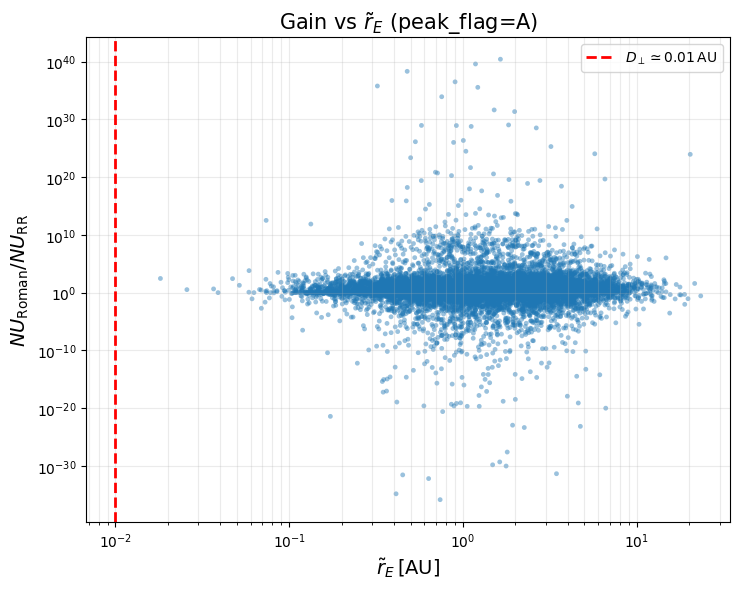

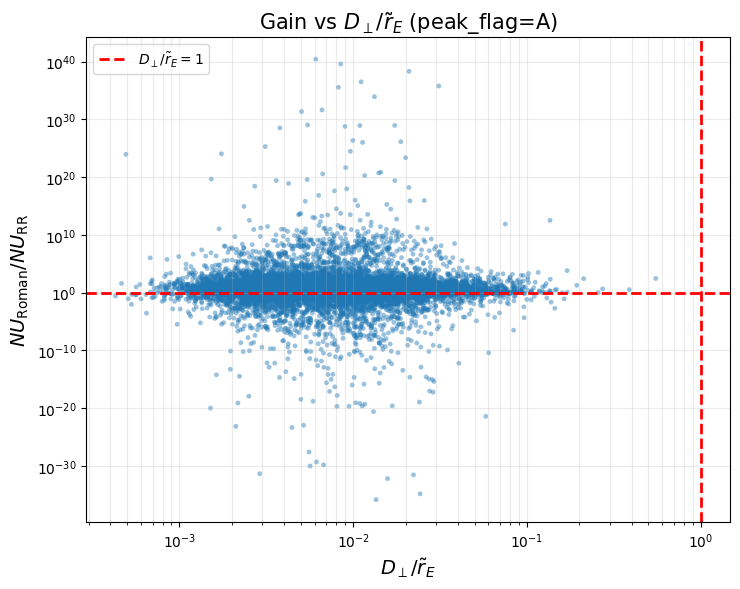

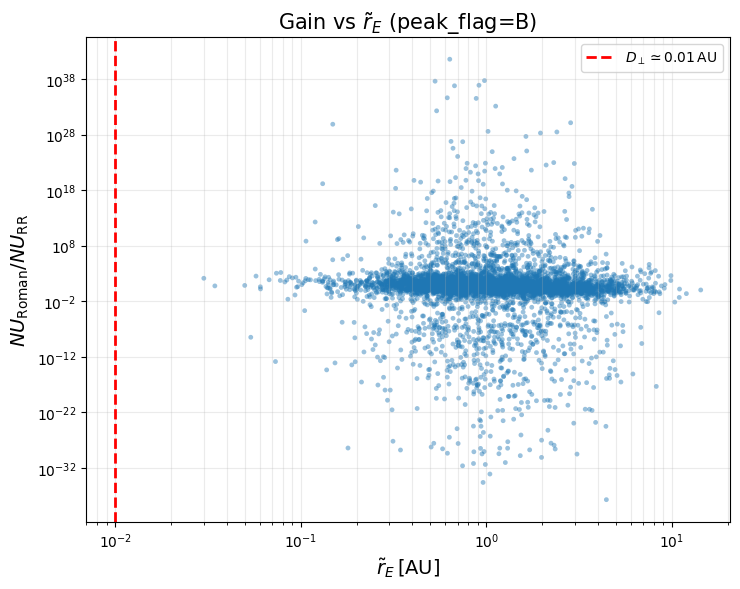

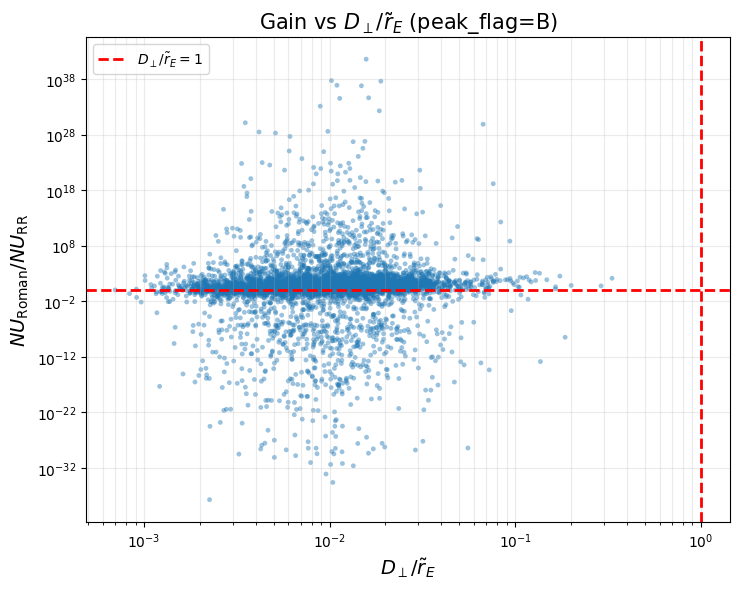

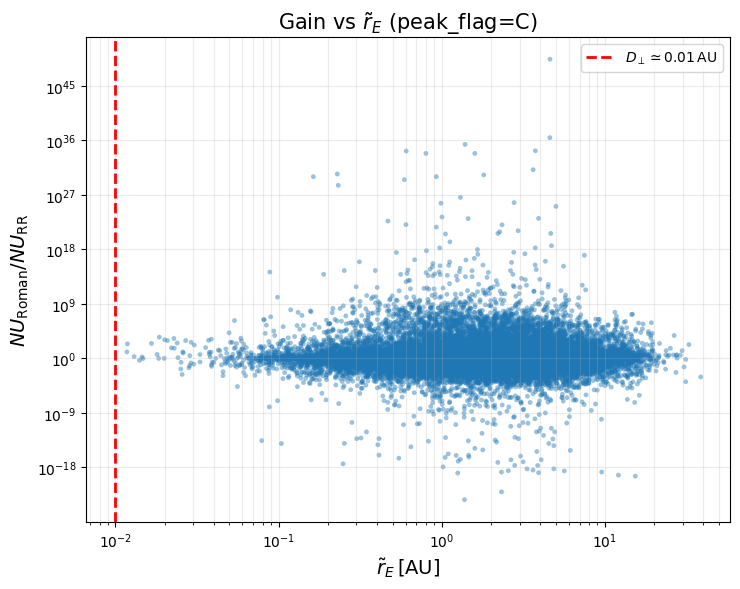

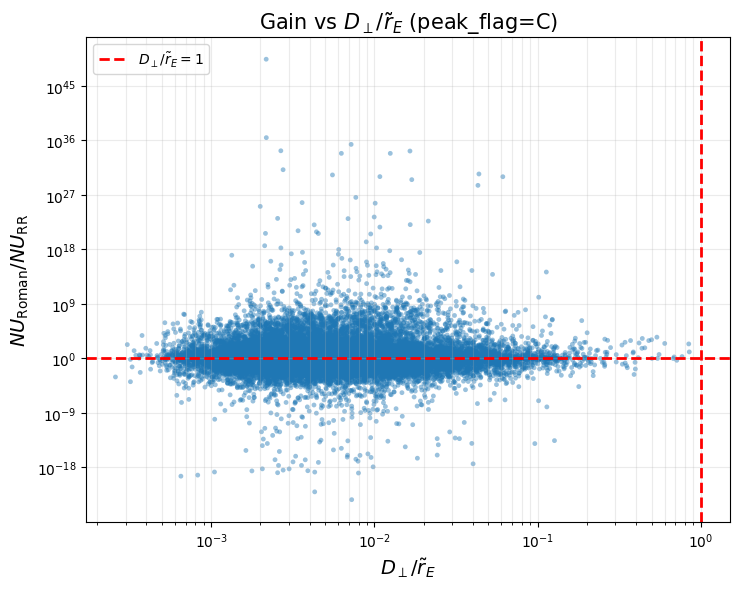

In [160]:

cols_id = ["Source", "Set"]

# ============================================================
# Merge incluyendo peak_flag
# ============================================================
df = true[cols_id + ["piE", "peak_flag"]].merge(
    met_3_roman[cols_id + ["piE"]],
    on=cols_id,
    how="inner",
    suffixes=("_true", "_NU_roman")
)

df = df.merge(
    met_3_rr[cols_id + ["piE"]],
    on=cols_id,
    how="inner"
)

df = df.rename(columns={"piE": "NU_rr"})

# ============================================================
# Cantidades físicas
# ============================================================
df["rE_tilde_AU"] = 1.0 / df["piE_true"]
df["gain"] = df["piE_NU_roman"] / df["NU_rr"]

D_perp = 0.01
df["Dperp_over_rEtilde"] = D_perp / df["rE_tilde_AU"]

# ============================================================
# Filtros
# ============================================================
mask = (
    np.isfinite(df["piE_true"]) &
    np.isfinite(df["piE_NU_roman"]) &
    np.isfinite(df["NU_rr"]) &
    np.isfinite(df["rE_tilde_AU"]) &
    np.isfinite(df["gain"]) &
    (df["piE_true"] > 0) &
    (df["piE_NU_roman"] > 0) &
    (df["NU_rr"] > 0) &
    (df["rE_tilde_AU"] > 0) &
    (df["gain"] > 0)
)

df = df[mask].copy()

# ============================================================
# Loop por categorías
# ============================================================
for flag in ["A", "B", "C"]:

    df_flag = df[df["peak_flag"] == flag]

    if len(df_flag) == 0:
        continue

    # =========================
    # Plot 1: rE_tilde
    # =========================
    fig, ax = plt.subplots(figsize=(7.5, 6))

    ax.scatter(
        df_flag["rE_tilde_AU"],
        df_flag["gain"],
        s=12,
        alpha=0.45,
        edgecolors="none"
    )

    ax.axvline(
        D_perp,
        color="red",
        linestyle="--",
        linewidth=2,
        label=rf"$D_\perp \simeq {D_perp:.2g}\,\mathrm{{AU}}$"
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(r"$\tilde r_E\,[\mathrm{AU}]$", fontsize=14)
    ax.set_ylabel(r"$NU_{\rm Roman}/NU_{\rm RR}$", fontsize=14)

    ax.set_title(
        rf"Gain vs $\tilde r_E$ (peak_flag={flag})",
        fontsize=15
    )

    ax.grid(True, which="both", alpha=0.25)
    ax.legend()

    plt.tight_layout()
    plt.show()

    # =========================
    # Plot 2: D_perp / rE_tilde
    # =========================
    fig, ax = plt.subplots(figsize=(7.5, 6))

    ax.scatter(
        df_flag["Dperp_over_rEtilde"],
        df_flag["gain"],
        s=12,
        alpha=0.45,
        edgecolors="none"
    )

    ax.axvline(
        1.0,
        color="red",
        linestyle="--",
        linewidth=2,
        label=r"$D_\perp/\tilde r_E = 1$"
    )

    ax.axhline(
        1.0,
        color="red",
        linestyle="--",
        linewidth=2
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(r"$D_\perp/\tilde r_E$", fontsize=14)
    ax.set_ylabel(r"$NU_{\rm Roman}/NU_{\rm RR}$", fontsize=14)

    ax.set_title(
        rf"Gain vs $D_\perp/\tilde r_E$ (peak_flag={flag})",
        fontsize=15
    )

    ax.grid(True, which="both", alpha=0.25)
    ax.legend()

    plt.tight_layout()
    plt.show()

In [25]:
# true.columns

In [22]:
from astropy import units as u
from astropy import constants as C
k = 4*C.G/(C.c**2)
thetaE = true["mass"]*k*true["piE"]
thetaE

0        5.133886e-30
1        2.994214e-29
2        1.136187e-29
3        1.164049e-29
5        2.406915e-29
             ...     
69478    6.422170e-30
69479    7.238245e-30
69480    2.520728e-29
69481    7.183133e-29
69482    1.791286e-29
Length: 63909, dtype: float64

In [148]:
# r_hat = 

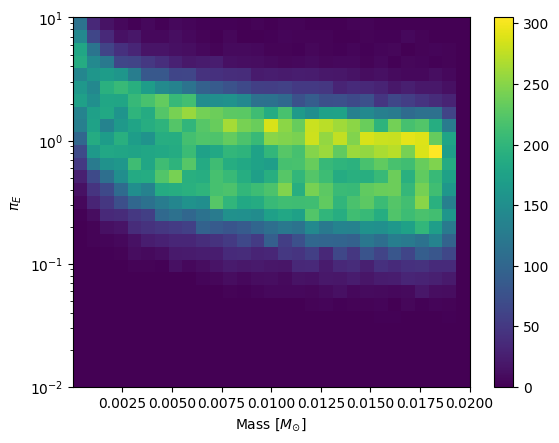

In [60]:
binesx = np.linspace(1e-5,0.02,30)
binesy = np.logspace(-2,1,30)
plt.hist2d(true["mass"],true["piE"],bins=(binesx,binesy))
plt.ylabel("$\pi_E$")
plt.xlabel(r"Mass $ [M_{\odot}] $")
plt.colorbar()
plt.yscale("log")
# plt.xscale("log")
plt.show()

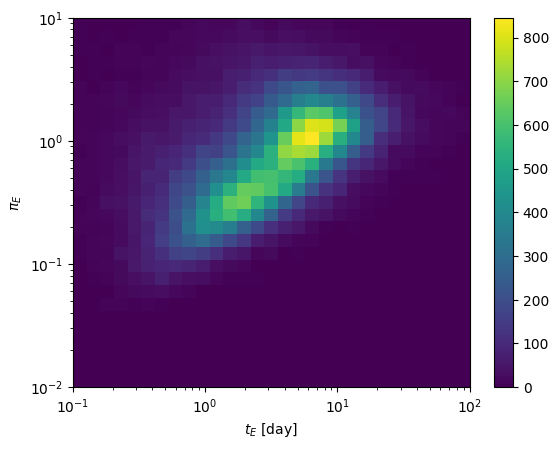

In [36]:
binesx = np.logspace(-1,2,30)
binesy = np.logspace(-2,1,30)
plt.hist2d(true["tE"],true["piE"],bins=(binesx,binesy))
plt.ylabel("$\pi_E$")
plt.xlabel(r"$t_E$ [day] ")
plt.colorbar()
plt.yscale("log")
plt.xscale("log")
plt.show()

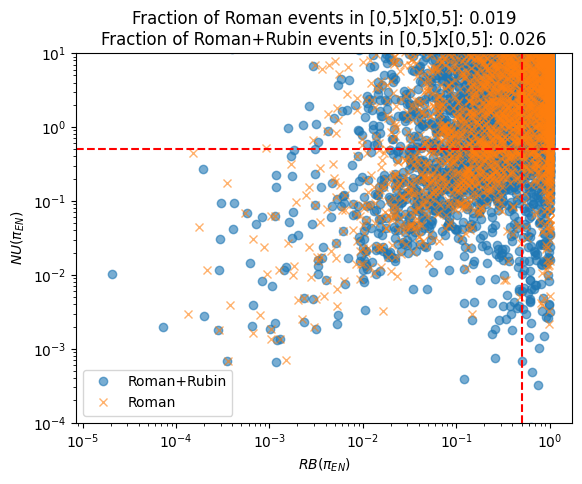

In [7]:

plt.close("all")
plt.plot(met_1_rr['piEN'], met_3_rr['piEN'],alpha=0.6, marker="o", linestyle='',label="Roman+Rubin")
mask = (met_1_rr['piEN'] < 0.5) & (met_3_rr['piEN'] < 0.5)
n_true = mask.sum()
frac_rr = n_true/len(met_1_rr['piEN'])
# plt.title(f"Fraction of Roman events in [0,5]x[0,5]: {n_true/len(met_1_rr['piEE'])}")

plt.plot(met_1_roman['piEN'], met_3_roman['piEN'],alpha=0.6, marker="x", linestyle='',label="Roman")
mask = (met_1_roman['piEN'] < 0.5) & (met_3_roman['piEN'] < 0.5)
n_true = mask.sum()
frac_rom =n_true/len(met_1_roman['piEN'])

plt.xscale("log")
plt.yscale("log")
plt.ylabel("$NU(\pi_{EN})$")
plt.xlabel("$RB(\pi_{EN})$")
plt.title(f"Fraction of Roman events in [0,5]x[0,5]: {round(frac_rom,3)}\n"+f"Fraction of Roman+Rubin events in [0,5]x[0,5]: {round(frac_rr,3)}")
plt.axvline(0.5,color='red',linestyle='--')
plt.axhline(0.5,color='red',linestyle='--')
plt.ylim(1e-4,1e1)
plt.legend(loc='best')
plt.show()


In [8]:
events_bad_fit = []

for p in params:
    events_bad_fit.append(
        fit_roman[fit_roman[p + '_err'] == 0][["Source", "Set"]]
    )

# Unión de todos los dataframes, quitando duplicados
events_bad_fit = (
    pd.concat(events_bad_fit, ignore_index=True)
      .drop_duplicates()
      .reset_index(drop=True)
)

# events_bad_fit


In [9]:
# events_bad_fit contiene ["Source", "Set"] sin duplicados

events_good_fits = (
    fit_roman
    .merge(events_bad_fit, on=["Source", "Set"], how="left", indicator=True)
)

# Filtrar solo las filas que NO estén en events_bad_fit
events_good_fits = events_good_fits[events_good_fits["_merge"] == "left_only"]

# Eliminar columna auxiliar
events_good_fits = events_good_fits.drop(columns="_merge").reset_index(drop=True)
events_good_fits

,Source,Set,t0,u0,tE,rho,piEN,piEE,t0_err,u0_err,...,piE_err,chichi,dof,mass_v1,mass_v2,err_mass_v1,err_mass_v2,mass_v3,err_mass_v3,ln_likelihood
0,100,1,2.461662e+06,2.014036,0.032461,3.397093e-02,0.378100,2.572973e-03,0.291641,561.835574,...,19677.737663,54352.573134,51598,0.004571,0.000200,1.123957e-07,3.810226e-07,2.297506e-03,3.879169e-11,45921.762216
1,10007,1,2.462911e+06,-0.117828,9.208753,5.124955e-03,1.097615,5.454925e-01,0.021407,0.001525,...,1.670559,52260.733716,51598,0.008224,0.008238,4.929580e-03,4.878427e-03,4.567341e-03,9.989534e-04,96840.481319
2,10016,1,2.461476e+06,-2.083670,1.911114,1.579898e-40,-0.000100,1.428384e-38,7.553974,30.156533,...,3652.647562,51332.372943,51598,38.103851,35.037953,1.332515e-06,4.764637e-06,1.759478e+39,1.404288e-08,94948.940789
3,10018,1,2.462570e+06,0.035280,0.005684,1.017100e-02,-0.002817,-3.000041e-01,1.611735,5135.725767,...,23521.228749,117060.883987,51598,0.013062,0.000048,2.123341e-07,2.049778e-06,6.557384e-03,1.484201e-12,73878.760617
4,10034,1,2.462954e+06,0.884690,4.733923,8.008358e-03,0.000042,4.531622e-01,1.305067,1.172613,...,111.658124,51949.007614,51598,0.017881,0.018022,9.213284e-05,9.981917e-05,8.940313e-03,3.615378e-07,126231.271768
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63194,99959,4,2.461841e+06,0.481073,0.019669,6.141020e-04,0.000207,-7.254588e-01,0.327412,86.894410,...,203.994616,103750.011457,51598,0.002980,0.000078,1.360989e-05,3.280239e-05,4.101039e-02,3.681365e-11,59872.938295
63195,99960,4,2.461870e+06,2.463120,1.665480,1.431970e-03,0.407761,2.773614e-01,25.871364,101.635132,...,6086.674494,157536.658039,51598,0.004941,0.009804,5.075564e-07,1.716748e-05,4.366833e-02,1.544752e-09,187090.963581
63196,99961,4,2.462743e+06,0.082227,33.097355,5.161512e-03,-2.070360,-1.061750e+00,0.000968,0.000295,...,0.006881,51989.711188,51598,0.003647,0.003640,1.073766e-05,1.361729e-05,4.434282e-03,3.532241e-03,101361.989564
63197,99966,4,2.462759e+06,-1.646880,7.476264,2.368612e-03,2.866535,-8.044863e-01,0.187339,0.868649,...,12.744021,51835.568423,51598,0.008122,0.006940,2.367306e-03,1.997495e-03,4.061059e-03,2.748697e-06,71396.252823


In [10]:
# met_3_rr

In [11]:
cols = ['Source', 'Set', 'piE']
df_intersection = (
    met_3_rr.loc[met_3_rr['piE'] < 0.5, cols]
    .merge(
        met_3_roman.loc[met_3_roman['piE'] < 0.5, cols],
        on=['Source', 'Set'],
        how='inner',
        suffixes=('_rr', '_roman'))
    .sort_values(['Source', 'Set'])
    .reset_index(drop=True))
true_filtered_rerror = true.merge(df_intersection[["Source","Set"]], on=['Source', 'Set'], how='inner')
# true_filtered_rerror = true_filtered.merge(df_intersection[["Source","Set"]], on=['Source', 'Set'], how='inner')

In [12]:
cols = ['Source', 'Set']

df_rr_only = (
    met_3_rr.loc[met_3_rr['piE'] < 0.5, cols]
    .sort_values(['Source', 'Set'])
    .reset_index(drop=True)
)

df_roman_only = (
    met_3_roman.loc[met_3_roman['piE'] < 0.5, cols]
    .sort_values(['Source', 'Set'])
    .reset_index(drop=True)
)




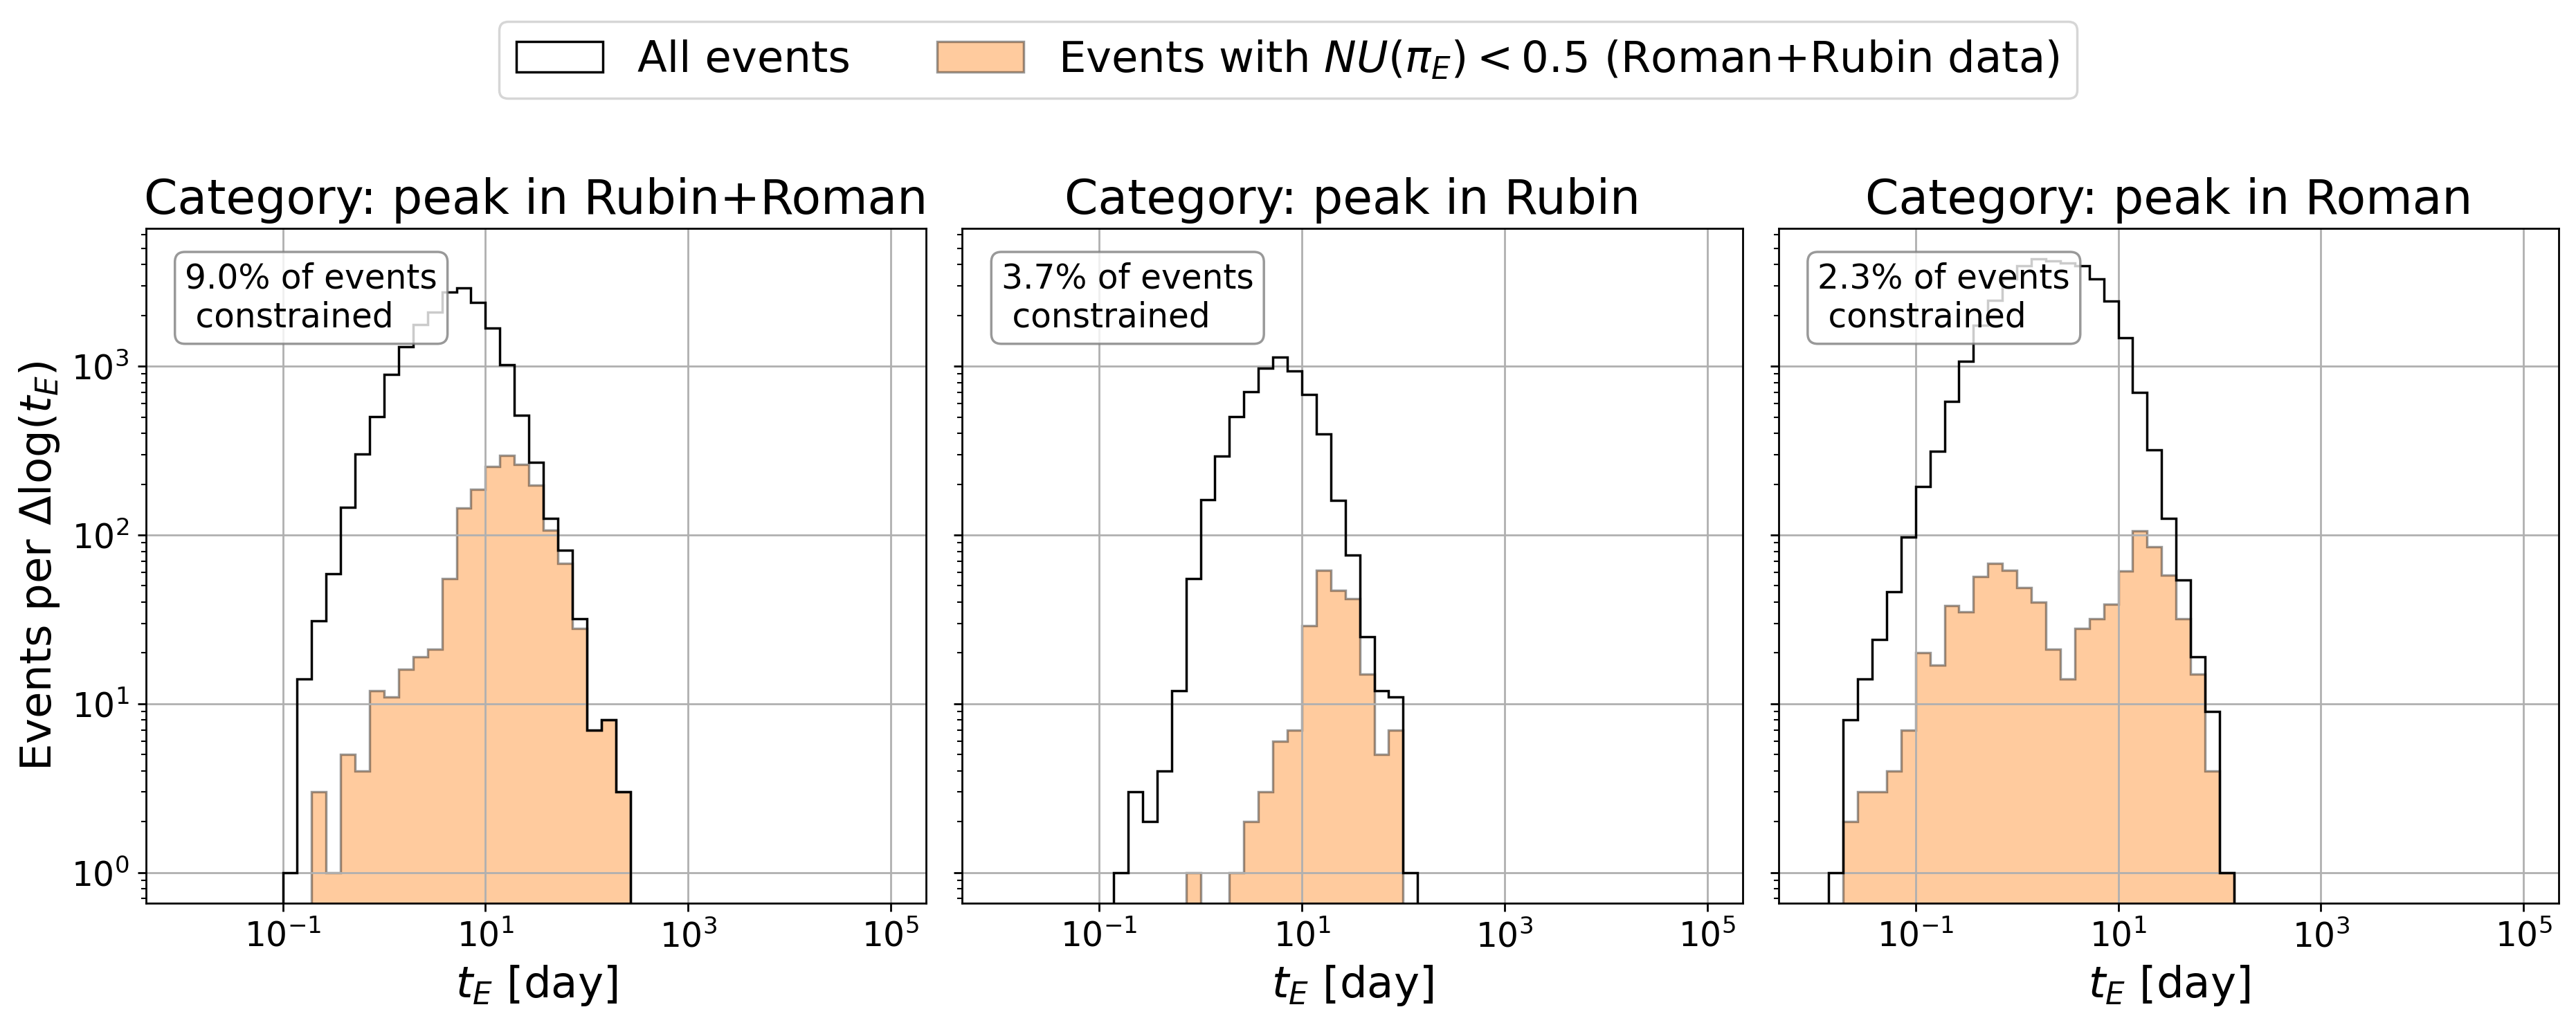

In [13]:
true_filtered_rerror = true.merge(
    df_rr_only,
    on=['Source', 'Set'],
    how='inner'
)
plt.close("all")
p = "tE"
bines  = np.logspace(-2, 5, 50)
hysttype_1 = "step"
hysttype_2 = "stepfilled"

title_new = lambda x: "Category: " + f"{x}"
label2 = "Events with $NU(\pi_E)<0.5$ (Roman+Rubin data)"
label1 = "All events"

categories = ["A", "B", "C"]

fig, axs = plt.subplots(1, 3, figsize=(15, 6), sharey=True, dpi=250)

for ax, cat in zip(axs, categories):

    df1 = true[true["peak_flag"] == cat]
    df2 = true_filtered_rerror[true_filtered_rerror["peak_flag"] == cat]
    
    N_total = len(df1)
    N_subset = len(df2)
    
    if N_total > 0:
        frac = 100 * N_subset / N_total
    else:
        frac = 0.0

    ax.hist(df1[p], bins=bines, histtype=hysttype_1,
            edgecolor='k', label=label1)

    ax.hist(df2[p], bins=bines, histtype=hysttype_2,
            edgecolor='k', alpha=0.4, label=label2)

    ax.annotate(
    f"{frac:.1f}% of events\n constrained",
    xy=(0.05, 0.95),              # posición relativa dentro del eje
    xycoords='axes fraction',
    fontsize=14,
    ha='left',
    va='top',
    bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8)
)


    ax.set_title(title_new(dict_cat_peak[cat]), fontsize=20)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True)
    ax.set_xlabel(p_labels[p] + " [day]", fontsize=18)

    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.tick_params(axis='both', which='minor', labelsize=12)

# Solo el primero lleva ylabel
axs[0].set_ylabel("Events per $\Delta \log (t_E)$", fontsize=18)

# Una sola leyenda
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=18)

plt.tight_layout(rect=[0, 0, 1, 0.85])

# if outdir is None:
outname = "FFP_piE<0.5_RR"
outdir = os.getcwd()

png_path = os.path.join(outdir, f"{outname}.png")
pdf_path = os.path.join(outdir, f"{outname}.pdf")

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()


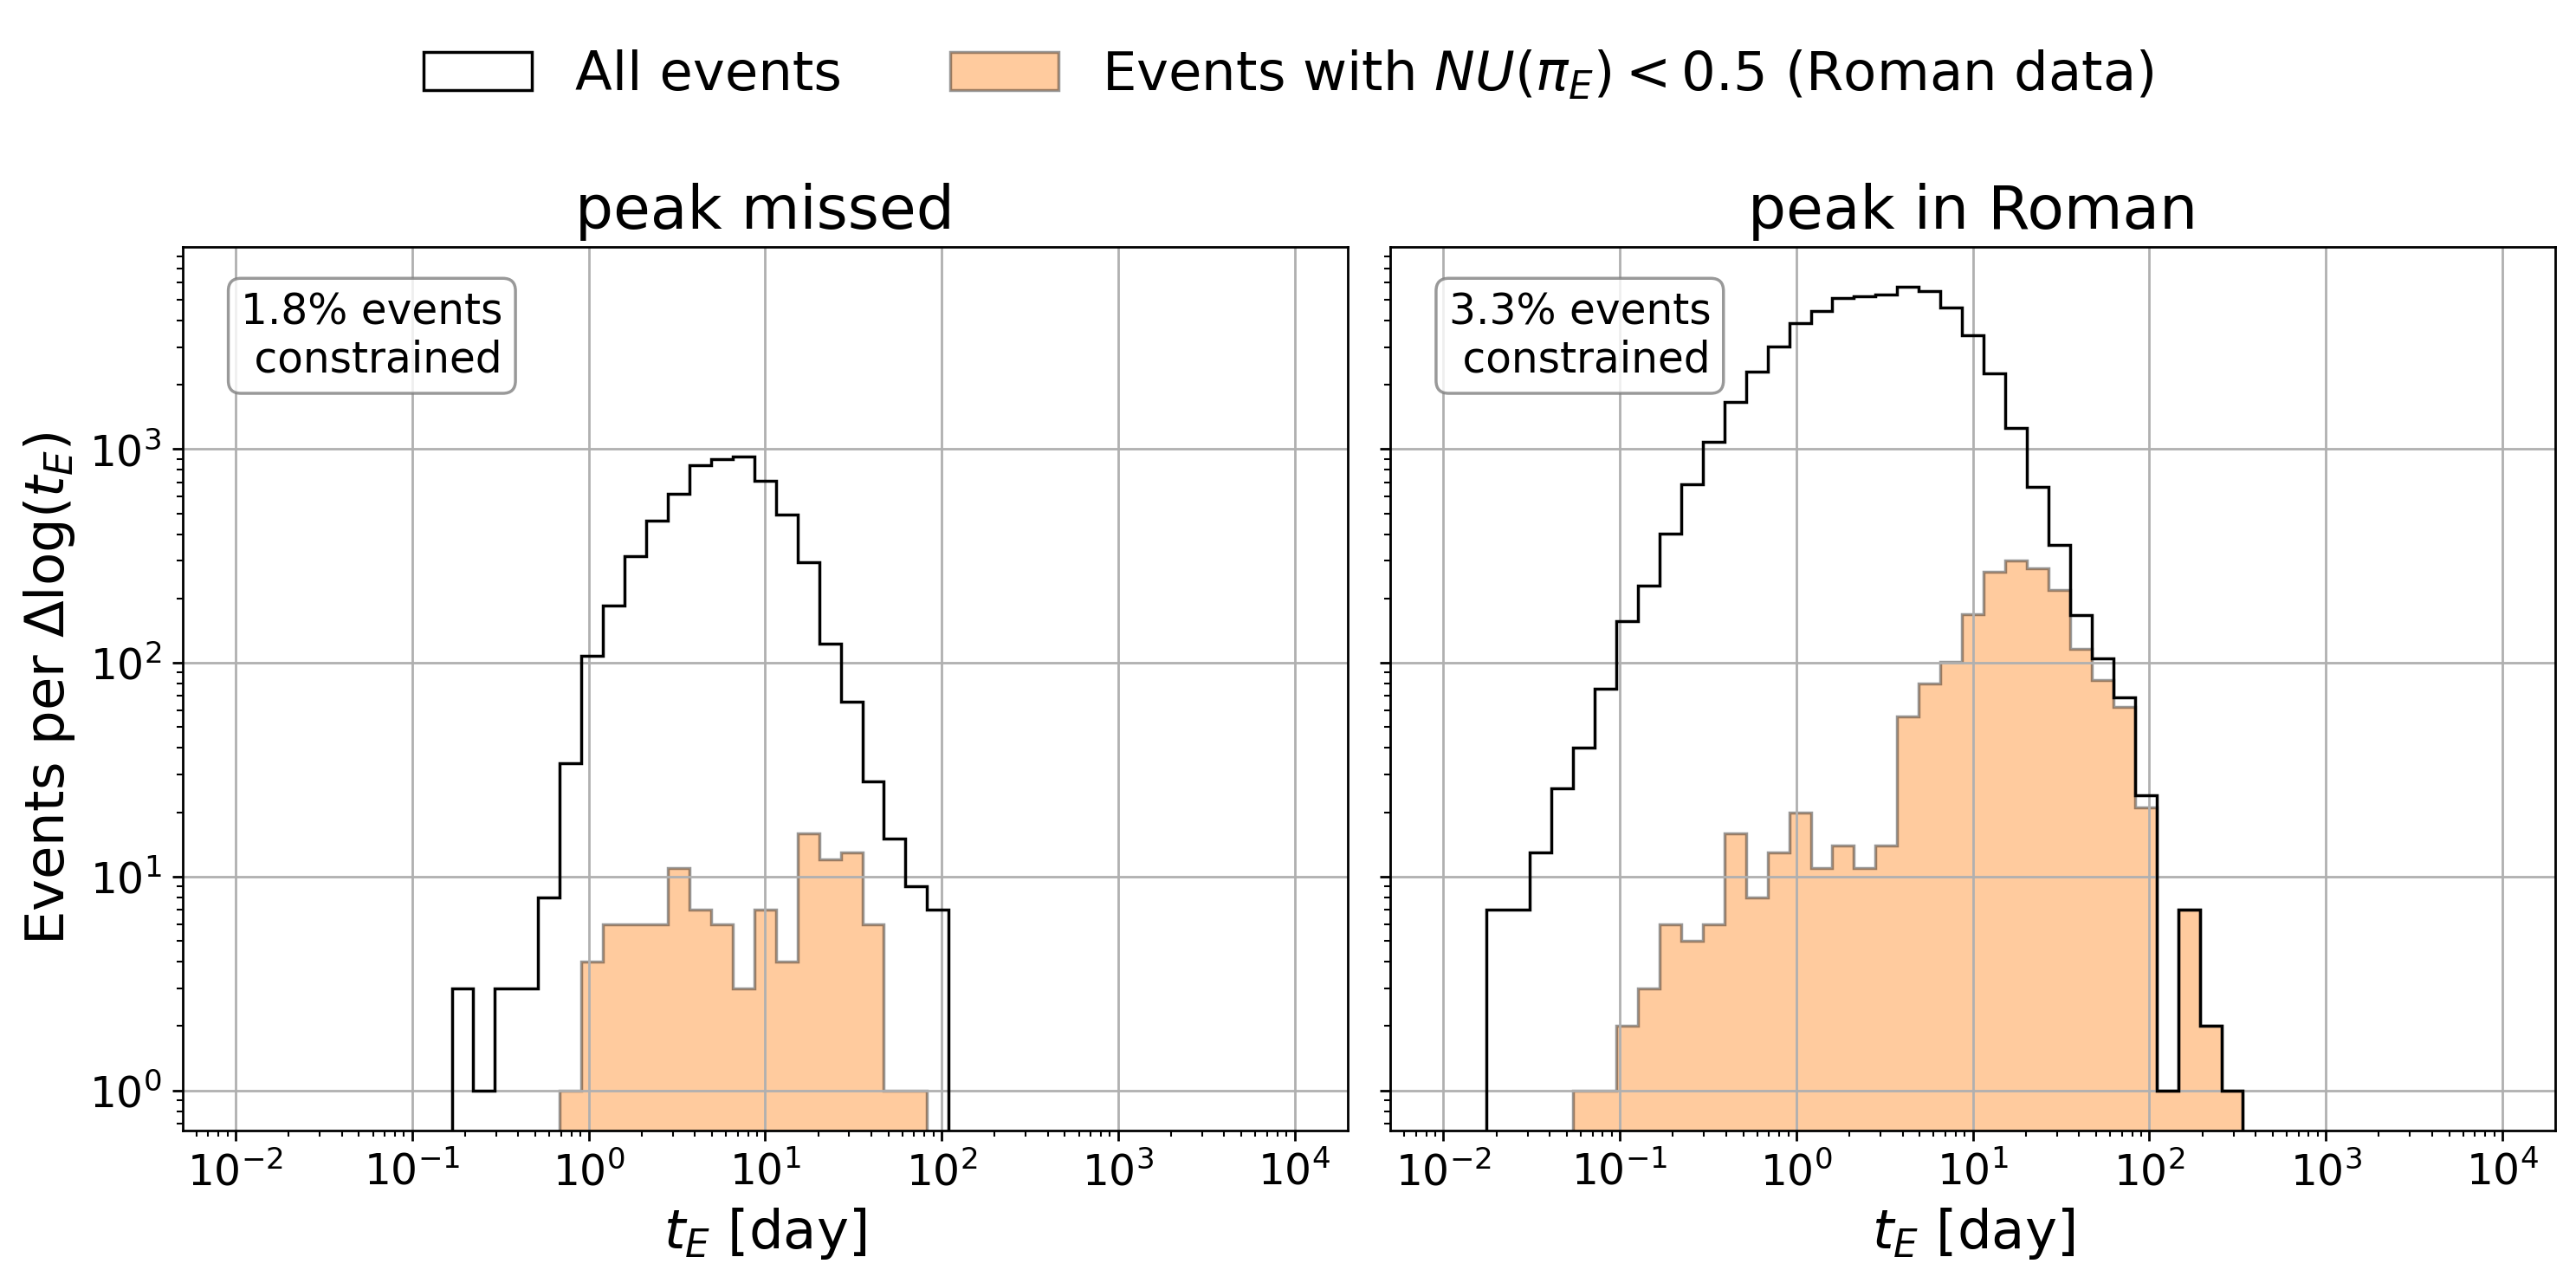

In [14]:
true_filtered_rerror = true.merge(
    df_roman_only,
    on=['Source', 'Set'],
    how='inner'
)
plt.close("all")

p = "tE"
dict_cat_peak_roman = {"A + C":"peak in Roman",
                "B":"peak missed"}
bines  = np.logspace(-2, 4, 50)
hysttype_1 = "step"
hysttype_2 = "stepfilled"

title_new = lambda x: x
label2 = "Events with $NU(\pi_E)<0.5$ (Roman data)"
label1 = "All events"

fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True,dpi=250)

# --- Definimos los dos grupos ---
groups = {
    "B": ["B"],
    "A + C": ["A", "C"]
}

for ax, (label_group, cats) in zip(axs, groups.items()):

    df1 = true[true["peak_flag"].isin(cats)]
    df2 = true_filtered_rerror[true_filtered_rerror["peak_flag"].isin(cats)]

    ax.hist(df1[p], bins=bines, histtype=hysttype_1,
            edgecolor='k', label=label1)

    ax.hist(df2[p], bins=bines, histtype=hysttype_2,
            edgecolor='k', alpha=0.4, label=label2)

    # --- porcentaje del subconjunto ---
    N_total = len(df1)
    N_subset = len(df2)
    frac = 100 * N_subset / N_total if N_total > 0 else 0

    ax.annotate(f"{frac:.1f}% events\n constrained",
                xy=(0.05, 0.95), xycoords='axes fraction',
                fontsize=14, ha='left', va='top',
                bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

    ax.set_title(dict_cat_peak_roman[title_new(label_group)], fontsize=20)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True)
    ax.set_xlabel(p_labels[p] + " [day]", fontsize=18)

    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.tick_params(axis='both', which='minor', labelsize=12)

axs[0].set_ylabel("Events per $\Delta \log (t_E)$", fontsize=18)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=18,frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.88])

outname = "FFP_piE<0.5_Roman"
outdir = os.getcwd()

png_path = os.path.join(outdir, f"{outname}.png")
pdf_path = os.path.join(outdir, f"{outname}.pdf")

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()


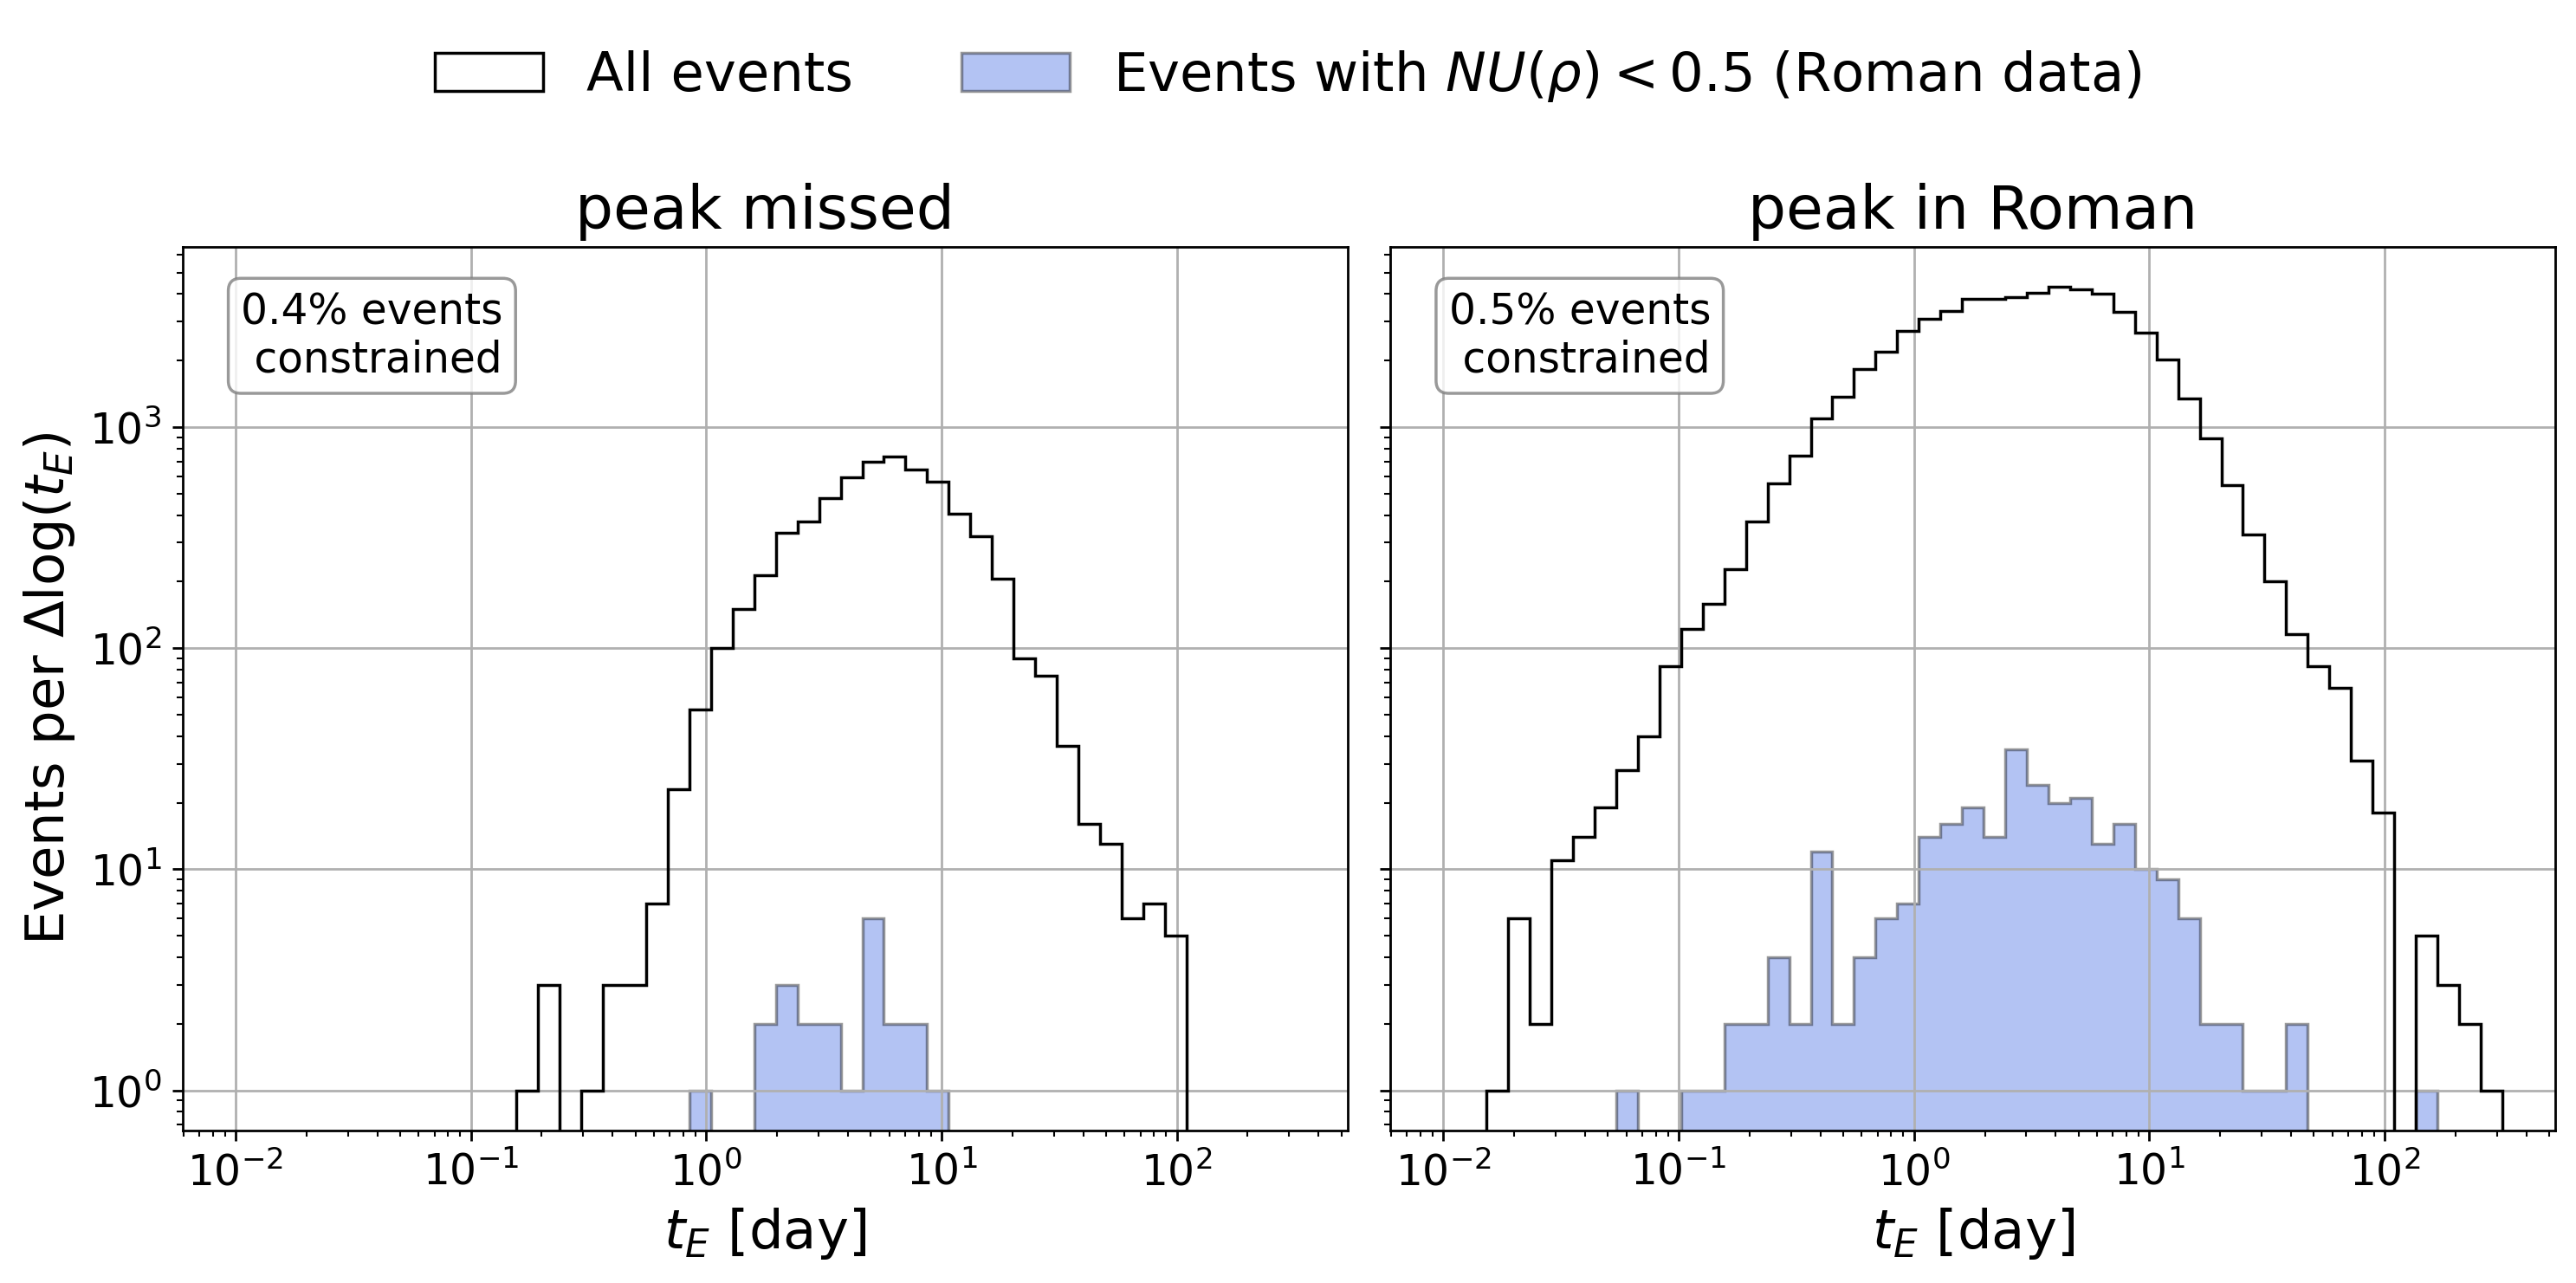

In [15]:
cols = ['Source', 'Set']
p='rho'
if p in params:
        
    df_roman_only = (
        met_3_roman.loc[met_3_roman[p] < 0.5, cols]
        .sort_values(['Source', 'Set'])
        .reset_index(drop=True)
    )
    
    true_filtered_rerror = true.merge(
        df_roman_only,
        on=['Source', 'Set'],
        how='inner'
    )
    plt.close("all")
    
    p = "tE"
    dict_cat_peak_roman = {"A + C":"peak in Roman",
                    "B":"peak missed"}
    bines  = np.logspace(-2, 2.5, 50)
    hysttype_1 = "step"
    hysttype_2 = "stepfilled"
    
    title_new = lambda x: x
    label2 = r"Events with $NU(\rho)<0.5$ (Roman data)"
    label1 = "All events"
    
    fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True,dpi=250)
    
    # --- Definimos los dos grupos ---
    groups = {
        "B": ["B"],
        "A + C": ["A", "C"]
    }
    
    for ax, (label_group, cats) in zip(axs, groups.items()):
    
        df1 = true[true["peak_flag"].isin(cats)]
        df2 = true_filtered_rerror[true_filtered_rerror["peak_flag"].isin(cats)]
    
        ax.hist(df1[p], bins=bines, histtype=hysttype_1,
                edgecolor='k', label=label1)
    
        ax.hist(df2[p], bins=bines, histtype=hysttype_2, color='royalblue',
                edgecolor='k', alpha=0.4, label=label2)
    
        # --- porcentaje del subconjunto ---
        N_total = len(df1)
        N_subset = len(df2)
        frac = 100 * N_subset / N_total if N_total > 0 else 0
    
        ax.annotate(f"{frac:.1f}% events\n constrained",
                    xy=(0.05, 0.95), xycoords='axes fraction',
                    fontsize=14, ha='left', va='top',
                    bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))
    
        ax.set_title(dict_cat_peak_roman[title_new(label_group)], fontsize=20)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True)
        ax.set_xlabel(p_labels[p] + " [day]", fontsize=18)
    
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.tick_params(axis='both', which='minor', labelsize=12)
    
    axs[0].set_ylabel("Events per $\Delta \log (t_E)$", fontsize=18)
    
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=18,frameon=False)
    
    plt.tight_layout(rect=[0, 0, 1, 0.88])
    
    outname = "FFP_piE<0.5_Roman"
    outdir = os.getcwd()
    
    png_path = os.path.join(outdir, f"{outname}.png")
    pdf_path = os.path.join(outdir, f"{outname}.pdf")
    
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()


Saved:
 - /home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/notebooks/BH-FFP/FFP_doublecut_rho_piE_lt_0p5_Roman_vs_RR.png
 - /home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/notebooks/BH-FFP/FFP_doublecut_rho_piE_lt_0p5_Roman_vs_RR.pdf


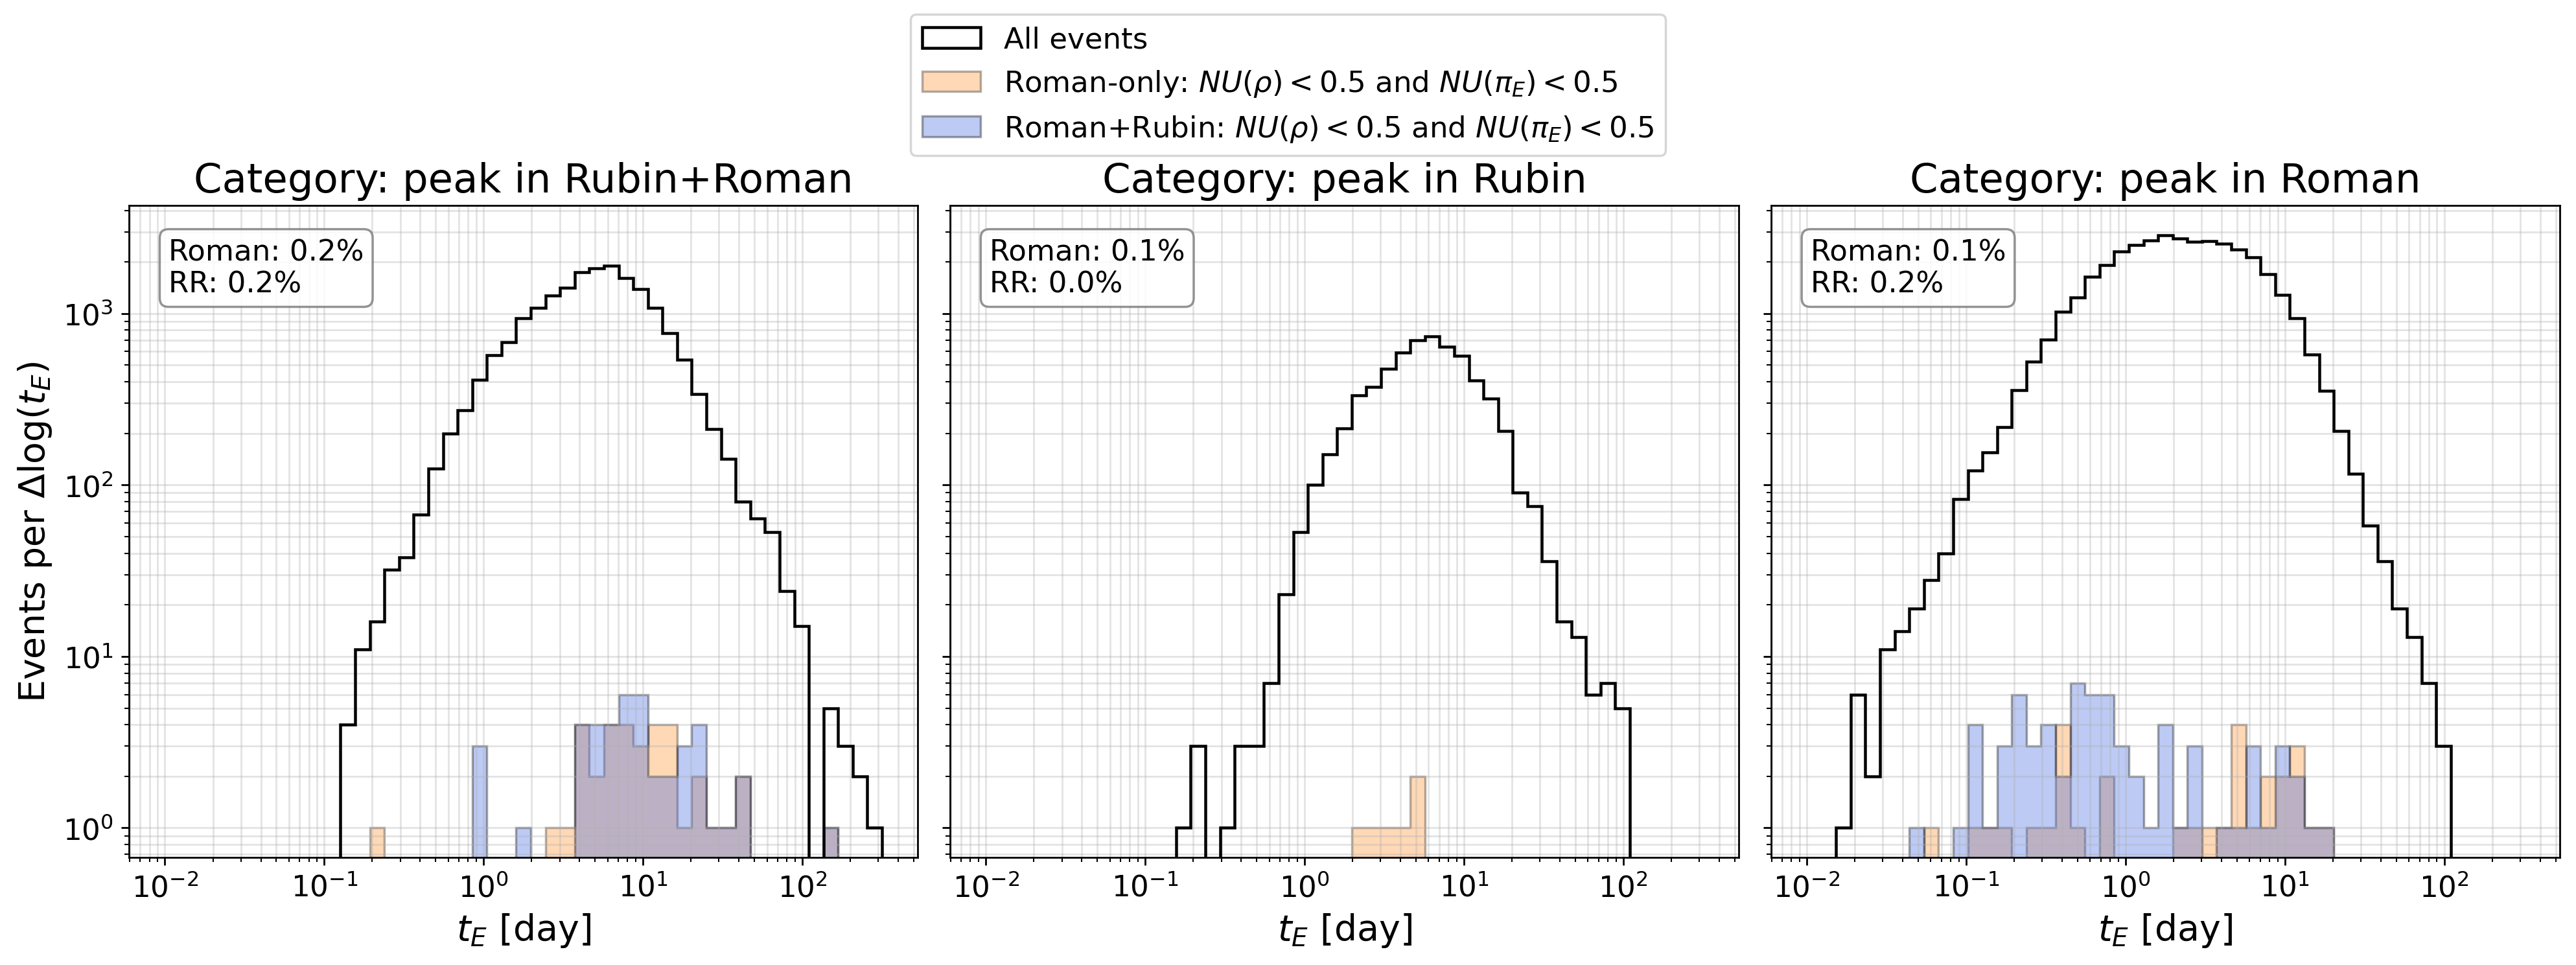

In [16]:

p='rho'
if p in params:
    THRESH = 0.5
    COLS_KEY = ["Source", "Set"]
    CATEGORIES = ["A", "B", "C"]
    PARAM_X = "tE"
    
    # Bins log para tE
    BINS_TE = np.logspace(-2, 2.5, 50)
    
    # Estilos de hist
    HIST_ALL = dict(histtype="step", edgecolor="k", linewidth=1.3)
    HIST_ROMAN = dict(histtype="stepfilled", edgecolor="k", alpha=0.30)  # color se setea en la llamada
    HIST_RR = dict(histtype="stepfilled", edgecolor="k", alpha=0.35)     # color se setea en la llamada
    
    
    # ============================================================
    # SELECCIÓN: eventos con (rho < THRESH) AND (piE < THRESH)
    # ============================================================
    roman_good = (
        met_3_roman.loc[
            (met_3_roman["rho"] < THRESH) & (met_3_roman["piE"] < THRESH),
            COLS_KEY
        ]
        .drop_duplicates()
        .sort_values(COLS_KEY)
        .reset_index(drop=True)
    )
    
    rr_good = (
        met_3_rr.loc[
            (met_3_rr["rho"] < THRESH) & (met_3_rr["piE"] < THRESH),
            COLS_KEY
        ]
        .drop_duplicates()
        .sort_values(COLS_KEY)
        .reset_index(drop=True)
    )
    
    # Cruzar con true para traer peak_flag, tE, etc.
    true_roman_good = true.merge(roman_good, on=COLS_KEY, how="inner")
    true_rr_good = true.merge(rr_good, on=COLS_KEY, how="inner")
    
    
    # ============================================================
    # FIGURA: 3 paneles (A/B/C). En cada panel:
    #   - All events (true)
    #   - Subset Roman-only (doble corte)
    #   - Subset Roman+Rubin (doble corte)
    # ============================================================
    plt.close("all")
    
    fig, axs = plt.subplots(1, 3, figsize=(16, 6), sharey=True, dpi=250)
    
    label_all = "All events"
    label_roman = rf"Roman-only: $NU(\rho)<{THRESH}$ and $NU(\pi_E)<{THRESH}$"
    label_rr = rf"Roman+Rubin: $NU(\rho)<{THRESH}$ and $NU(\pi_E)<{THRESH}$"
    
    for ax, cat in zip(axs, CATEGORIES):
    
        df_all = true[true["peak_flag"] == cat]
        df_rom = true_roman_good[true_roman_good["peak_flag"] == cat]
        df_rrc = true_rr_good[true_rr_good["peak_flag"] == cat]
    
        N_total = len(df_all)
        N_rom = len(df_rom)
        N_rrc = len(df_rrc)
    
        frac_rom = 100.0 * N_rom / N_total if N_total > 0 else 0.0
        frac_rrc = 100.0 * N_rrc / N_total if N_total > 0 else 0.0
    
        # Histograma: todos
        ax.hist(df_all[PARAM_X], bins=BINS_TE, label=label_all, **HIST_ALL)
    
        # Histograma: Roman-only (doble corte)
        ax.hist(df_rom[PARAM_X], bins=BINS_TE, color="tab:orange", label=label_roman, **HIST_ROMAN)
    
        # Histograma: RR (doble corte)
        ax.hist(df_rrc[PARAM_X], bins=BINS_TE, color="royalblue", label=label_rr, **HIST_RR)
    
        # Anotación con fracciones
        ax.annotate(
            f"Roman: {frac_rom:.1f}%\nRR: {frac_rrc:.1f}%",
            xy=(0.05, 0.95),
            xycoords="axes fraction",
            fontsize=13,
            ha="left",
            va="top",
            bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.85),
        )
    
        # Título y ejes
        ax.set_title("Category: " + f"{dict_cat_peak[cat]}", fontsize=18)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, which="both", alpha=0.35)
        ax.set_xlabel(p_labels.get(PARAM_X, PARAM_X) + " [day]", fontsize=16)
    
        ax.tick_params(axis="both", which="major", labelsize=13)
        ax.tick_params(axis="both", which="minor", labelsize=11)
    
    # ylabel sólo a la izquierda
    axs[0].set_ylabel(r"Events per $\Delta \log(t_E)$", fontsize=16)
    
    # Leyenda única (global), tomando handles del primer eje
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=1, fontsize=13)
    
    plt.tight_layout(rect=[0, 0, 1, 0.86])
    
    # ============================================================
    # GUARDAR
    # ============================================================
    outdir = os.getcwd()
    outname = f"FFP_doublecut_rho_piE_lt_{str(THRESH).replace('.','p')}_Roman_vs_RR"
    
    png_path = os.path.join(outdir, f"{outname}.png")
    pdf_path = os.path.join(outdir, f"{outname}.pdf")
    
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    
    print("Saved:")
    print(" -", png_path)
    print(" -", pdf_path)
    
    plt.show()



In [17]:
met_3_rr[met_3_rr["tE"]<0.5]

,Source,Set,t0,u0,tE,rho,piEN,piEE,piE,mass_v1,mass_v2,mass_v3
1,10007,1,8.914350e-09,0.012810,0.004847,1.609630e+01,2.677177e+00,0.274078,1.444262,0.571903,0.570749,1.100486e-01
3,10018,1,4.055768e-07,4.127103,0.189962,3.632758e+02,3.294292e+03,41.772318,772.536655,0.001609,0.001626,1.378875e-05
4,10034,1,4.844776e-08,0.124630,0.051776,1.338594e+02,4.972962e+08,1.439109,22.453095,0.056666,0.056946,1.168382e-03
6,10043,1,4.594385e-09,0.023468,0.015778,1.964151e+01,2.686152e+00,0.121214,1.517049,0.621685,0.605670,9.525936e-02
11,10073,1,2.411256e-09,0.020287,0.024456,8.029102e+01,2.360172e+00,0.115919,1.284691,0.602637,0.607865,2.435702e-02
...,...,...,...,...,...,...,...,...,...,...,...,...
63900,99931,4,2.442318e-08,0.489533,0.319455,5.717581e+02,1.427439e+03,62.392534,218.050205,0.005341,0.005450,2.829605e-05
63905,99960,4,7.577564e-08,0.701530,0.135838,9.929473e+03,8.000234e+01,100.913445,43.724569,0.015686,0.016143,5.581003e-06
63906,99961,4,3.929542e-10,0.004576,0.001627,1.851747e+00,3.057124e-03,0.004157,0.002957,0.002954,0.003725,1.114347e+00
63907,99966,4,7.606862e-08,0.527474,0.319055,1.394977e+03,7.336859e+00,0.671486,4.270565,0.291075,0.291155,6.715882e-04


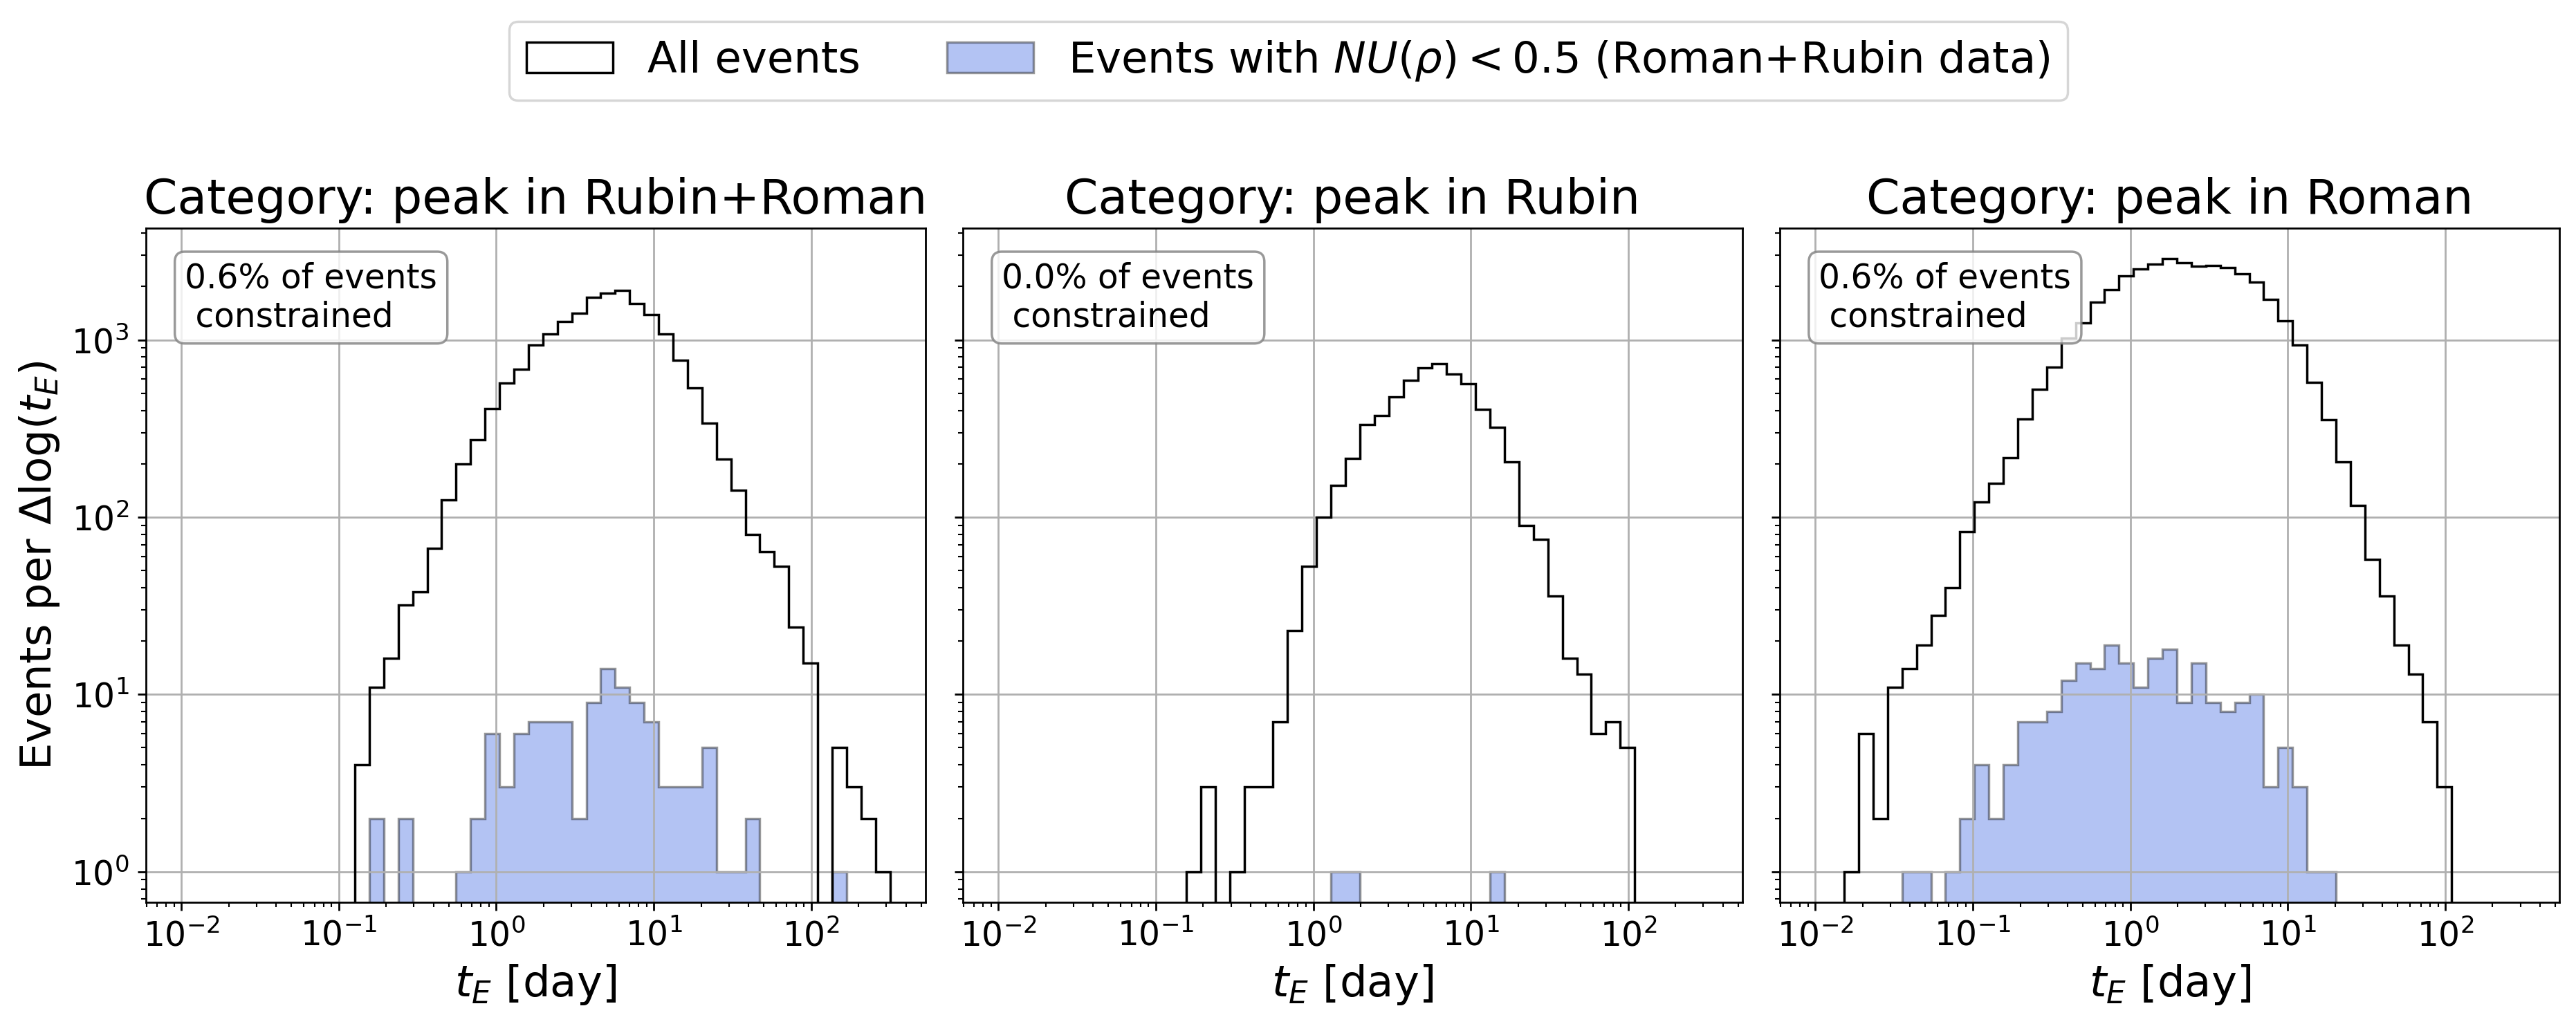

In [18]:

p ='rho'
if p in params:
            
    df_rr_only = (
        met_3_rr.loc[met_3_rr[p] < 0.5, cols]
        .sort_values(['Source', 'Set'])
        .reset_index(drop=True)
    )
    
    true_filtered_rerror = true.merge(
        df_rr_only,
        on=['Source', 'Set'],
        how='inner'
    )
    
    plt.close("all")
    p = "tE"
    bines  = np.logspace(-2, 2.5, 50)
    hysttype_1 = "step"
    hysttype_2 = "stepfilled"
    
    title_new = lambda x: "Category: " + f"{x}"
    label2 = r"Events with $NU(\rho)<0.5$ (Roman+Rubin data)"
    label1 = "All events"
    
    categories = ["A", "B", "C"]
    
    fig, axs = plt.subplots(1, 3, figsize=(15, 6), sharey=True, dpi=250)
    
    for ax, cat in zip(axs, categories):
    
        df1 = true[true["peak_flag"] == cat]
        df2 = true_filtered_rerror[true_filtered_rerror["peak_flag"] == cat]
        
        N_total = len(df1)
        N_subset = len(df2)
        
        if N_total > 0:
            frac = 100 * N_subset / N_total
        else:
            frac = 0.0
    
        ax.hist(df1[p], bins=bines, histtype=hysttype_1,
                edgecolor='k', label=label1)
    
        ax.hist(df2[p], bins=bines, histtype=hysttype_2, color='royalblue',
                edgecolor='k', alpha=0.4, label=label2)
    
        ax.annotate(
        f"{frac:.1f}% of events\n constrained",
        xy=(0.05, 0.95),              # posición relativa dentro del eje
        xycoords='axes fraction',
        fontsize=14,
        ha='left',
        va='top',
        bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8)
    )
    
    
        ax.set_title(title_new(dict_cat_peak[cat]), fontsize=20)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True)
        ax.set_xlabel(p_labels[p] + " [day]", fontsize=18)
    
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.tick_params(axis='both', which='minor', labelsize=12)
    
    # Solo el primero lleva ylabel
    axs[0].set_ylabel("Events per $\Delta \log (t_E)$", fontsize=18)
    
    # Una sola leyenda
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=18)
    
    plt.tight_layout(rect=[0, 0, 1, 0.85])
    
    # if outdir is None:
    outname = "FFP_piE<0.5_RR"
    outdir = os.getcwd()
    
    png_path = os.path.join(outdir, f"{outname}.png")
    pdf_path = os.path.join(outdir, f"{outname}.pdf")
    
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()


In [25]:
# for j in range(len(true)):
j=0
Source=true["Source"].iloc[j]
Set=true["Set"].iloc[j]
data_TRILEGAL = path_data+f"/TRILEGAL_chunk_{Set}.csv"
data_Genulens = path_data+f"/Genulens_chunk_{Set}.csv"

seed = Source
i=seed
np.random.seed(seed)
ROW_G = np.random.randint(0, 10000)
ROW_T = np.random.randint(0, 10000)

# (Esto se podría optimizar con caches de DataFrames, pero lo dejo igual por ahora)
TRILEGAL_row = pd.read_csv(
    data_TRILEGAL,
    skiprows=lambda x: x not in (0, ROW_T + 1)
)
GENULENS_row = pd.read_csv(
    data_Genulens,
    skiprows=lambda x: x not in (0, ROW_G + 1)
)

magstar = TRILEGAL_row[["W149", "u", "g", "r", "i", "z", "Y"]].iloc[0]
event_params = {
    **magstar.to_dict(),
    **event_param(i, TRILEGAL_row.iloc[0], GENULENS_row.iloc[0], system_type)
}
event_params
thetas = event_params['thetas']
print(thetas)
thetaE = event_params['thetaE']
# true.iloc["theta_E"] = thetaE
# true.iloc["theta_source"] = thetas

0.000240331202868601


In [33]:
true

,Source,Set,t0,u0,tE,rho,piEN,piEE,Category,mass,...,u_peak,u_npeak,u_lpeak,u_rpeak,peak_flag,flag_relevance,total_npeak,flag_total_npeak_gt10,theta_E,theta_source
0,100.0,1.0,2.461653e+06,1.379105,0.741328,0.017075,0.224941,0.234854,None,0.005315,...,0.0,0.0,NaN,NaN,C,True,44.0,1.0,0.014075,0.000240
1,10007.0,1.0,2.462911e+06,-0.117783,9.192547,0.002846,0.549593,0.519165,None,0.013333,...,0.0,0.0,NaN,NaN,A,True,550.0,1.0,0.082090,0.000234
2,10016.0,1.0,2.461476e+06,-1.814517,2.078341,0.007295,-0.237724,0.091874,None,0.015008,...,0.0,0.0,NaN,NaN,C,True,123.0,1.0,0.031150,0.000227
3,10018.0,1.0,2.462563e+06,0.445721,1.550059,0.005106,-0.166253,-0.223341,None,0.014075,...,0.0,0.0,NaN,NaN,C,True,92.0,1.0,0.031914,0.000163
5,10034.0,1.0,2.462954e+06,0.896718,4.696767,0.004004,0.059508,0.629892,None,0.012807,...,0.0,0.0,NaN,NaN,A,True,284.0,1.0,0.094233,0.000616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.141573,0.000220
12552,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.079043,0.000289
12563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.044355,0.000223
12565,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.147769,0.000187


In [38]:
def compute_theta(row):
    Source = int(row["Source"])
    Set = int(row["Set"])

    data_TRILEGAL = path_data + f"/TRILEGAL_chunk_{Set}.csv"
    data_Genulens = path_data + f"/Genulens_chunk_{Set}.csv"

    np.random.seed(Source)
    ROW_G = np.random.randint(0, 10000)
    ROW_T = np.random.randint(0, 10000)

    TRILEGAL_row = pd.read_csv(
        data_TRILEGAL,
        skiprows=lambda x: x not in (0, ROW_T + 1)
    )
    GENULENS_row = pd.read_csv(
        data_Genulens,
        skiprows=lambda x: x not in (0, ROW_G + 1)
    )

    magstar = TRILEGAL_row[["W149", "u", "g", "r", "i", "z", "Y"]].iloc[0]

    event_params = {
        **magstar.to_dict(),
        **event_param(Source, TRILEGAL_row.iloc[0], GENULENS_row.iloc[0], system_type)
    }

    return event_params["thetaE"], event_params["thetas"]

from joblib import Parallel, delayed

results = Parallel(n_jobs=-1)(
    delayed(compute_theta)(row)
    for _, row in true.iterrows()
)


KeyboardInterrupt

Process LokyProcess-10:
Process LokyProcess-11:
Process LokyProcess-2:
Process LokyProcess-5:
Process LokyProcess-8:
Process LokyProcess-12:
Process LokyProcess-9:
Process LokyProcess-1:
Process LokyProcess-7:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/anibal-pc/anaconda3/envs/rubin-sim/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
Traceback (most recent call last):
  File "/home/anibal-pc/anaconda3/envs/rubin-sim/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/anibal-pc/anaconda3/envs/rubin-sim/lib/python3.12/site-packages/joblib/parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, arg

In [19]:
p = "rho" if ("rho" in true.columns) else "piE"

if p in params:
    time = np.logspace(-2,2,50)
    
    all_ratios = []  # <- acumulador
    
    for k, met in enumerate([[met_1_rr, met_1_roman],
                             [met_2_rr, met_2_roman],
                             [met_3_rr, met_3_roman]]):
    
        for cat in ["A","B","C"]:
            for t_tresh in range(len(time)-1):
                ti, tf = time[t_tresh], time[t_tresh+1]
    
                keys = true.loc[
                    (true["peak_flag"]==cat) & (true["tE"]>ti) & (true["tE"]<tf),
                    ["Source","Set"]
                ]
                m_rr    = met[0].merge(keys, on=["Source","Set"], how="inner").dropna(subset=[p]).set_index(["Source","Set"])
                m_roman = met[1].merge(keys, on=["Source","Set"], how="inner").dropna(subset=[p]).set_index(["Source","Set"])
    
                common = m_rr.index.intersection(m_roman.index)
                m_rr, m_roman = m_rr.loc[common].sort_index(), m_roman.loc[common].sort_index()
    
                # filtro en RR y re-sincronizo
                m_rr = m_rr[m_rr[p] < 0.5]
                if m_rr.empty:
                    continue
                m_roman = m_roman.loc[m_rr.index]
    
                # construir df_ratio de ESTE bin/categoría y ACUMULAR
                df_ratio = (m_rr[p] / m_roman[p]).rename("ratio").reset_index()
                df_ratio["tE_min"] = ti
                df_ratio["tE_max"] = tf
                df_ratio["peak_flag"] = cat
                df_ratio["metric_id"] = k + 1  # opcional, por si querés saber qué métrica
                all_ratios.append(df_ratio)
    
    # concatenar TODO al final
    df_all = pd.concat(all_ratios, ignore_index=True)


In [19]:
binsx = np.logspace(-3, 3, 30)
binsy = np.logspace(-0.5, 0.5, 30)

cat= 'A'
p = 'piE'
x3 = met1_ratio.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]
y3 = met3_ratio.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]

lab_piE = [r"$\frac{|\pi_E - \hat{\pi}_E|_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|_{Roman}}$",r"$\frac{\sigma_{\pi_E}/\hat{\pi}_E(Roman+Rubin)}{\sigma_{\pi_E}/\hat{\pi}_E(Roman)}$"]
lab_rho = [r"$\frac{|\rho - \hat{\rho}|_{Roman+Rubin}}{|\rho - \hat{\rho}|_{Roman}}$",r"$\frac{\sigma_{\rho}/\hat{\rho}(Roman+Rubin)}{\sigma_{\rho}/\hat{\rho}(Roman)}$"]


In [21]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)
cat, p = 'C', 'piE'
binsx = np.logspace(-6, 0.1, 30)
binsy = np.logspace(-5, 7, 30)
y = met1_ratio.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]
x1 = met_1_rr_filtered.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]
x2 = met_1_roman_filtered.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')[p]
create_scatter_with_marginals(axes, x1,x2,y, [r"$\frac{|\pi_E - \hat{\pi}_E|}{\pi_E}$",r"$\frac{|\pi_E - \hat{\pi}_E|_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|_{Roman}}$"], 'piE',binsx,binsy)
plt.show()

In [ ]:
# Example usage
fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)#, gridspec_kw={'width_ratios': [1,1]})
cat= 'B'
binsx = np.logspace(-15, 5, 30)
binsy = np.logspace(-15, 5, 30)
y = met2_ratio.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
x1 = met_2_rr_filtered.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
x2 = met_2_roman_filtered.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
print(len(x1))

create_scatter_with_marginals(axes, x1,x2,y, [r"$\frac{|\pi_E - \hat{\pi}_E|}{\sigma(\pi_E)}$",r"$\frac{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman+Rubin}}{|\pi_E - \hat{\pi}_E|/\sigma(\hat{\pi}_E)_{Roman}}$"], 'piE',binsx,binsy)

plt.show()

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)
cat= 'C'
binsx = np.logspace(-3, 3, 30)
binsy = np.logspace(-6, 1, 30)
y = met3_ratio.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
x1 = met_3_rr_filtered.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']
x2 = met_3_roman_filtered.merge(true_filtered_rerror[true_filtered_rerror["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')['piE']

create_scatter_with_marginals(axes, x1,x2,y, [r"$\frac{\sigma(\hat{\pi}_E)}{\hat{\pi}_E}$",r"$\frac{\sigma(\hat{\pi}_E)/ \hat{\pi}_E (Roman+Rubin)}{\sigma(\hat{\pi}_E)/ \hat{\pi}_E (Roman)}$"], 'piE',binsx,binsy)

plt.show()

# Compute mass 

In [26]:
# met_3_rr[met_3_rr["mass_v3"]<0.5]

In [22]:
keys = ["Source", "Set"]
p= "piE"
s_rr    = met_2_rr.set_index(keys)[p]
s_roman = met_2_roman.set_index(keys)[p]
# Limitar al cruce de claves presentes en ambos DF
common = s_rr.index.intersection(s_roman.index)
mass_mask = (s_rr.loc[common] / s_roman.loc[common]) < 1
# mass_mask es un Series booleano indexado por (Source, Set)
# Si querés el mask en el orden de met_1_rr (incluyendo claves sin par en Roman):
mass_mask_rr_order = mass_mask.reindex(met_1_rr.set_index(keys).index)
keys = ["Source", "Set"]
# Asegurar que mass_mask tenga MultiIndex y esté bien alineada
mask = mass_mask.reindex(true.set_index(keys).index).fillna(False)
# Seleccionar las filas correspondientes
df_selected = true.loc[mask.values]
# df_selected
keys = ["Source", "Set"]
# Índices donde la condición es Fals
false_keys = mass_mask[~mass_mask].index
# Seleccionar en otro DataFrame (por coincidencia de claves)
df_not_selected = true.loc[
    true.set_index(keys).index.isin(false_keys)
]

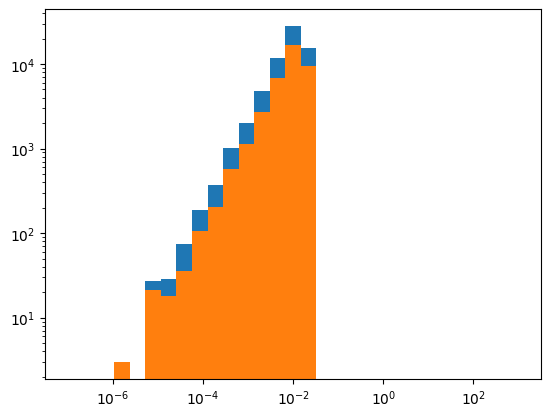

In [23]:
# plt.hist(plt.scatter(df_selected['mass'],df_selected['piE'],alpha=0.5)
plt.hist(true['mass'], bins=np.logspace(-7,3,30))
plt.hist(df_not_selected['mass'], bins=np.logspace(-7,3,30))#,df_not_selected['piE'],alpha=0.5))
plt.xscale("log")
plt.yscale("log")

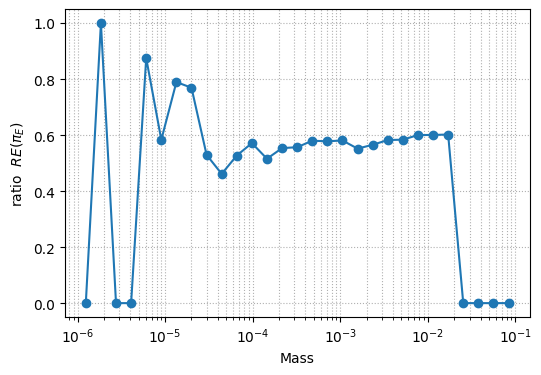

In [24]:
# Definir los mismos bins logarítmicos
bins = np.logspace(-6, -1, 30)
# Calcular histogramas (sin dibujar todavía)
counts_true, edges = np.histogram(true["mass"], bins=bins)
counts_not, _     = np.histogram(df_not_selected["mass"], bins=bins)
# Evitar división por cero
ratio = np.divide(counts_not, counts_true, out=np.zeros_like(counts_true, dtype=float), where=counts_true>0)
# Calcular centro de cada bin
centers = (edges[:-1] + edges[1:]) / 2
# Graficar
plt.figure(figsize=(6,4))
plt.plot(centers, ratio, marker='o')
plt.xscale("log")
plt.yscale("linear")  # el cociente no suele necesitar escala log
plt.xlabel("Mass")
plt.ylabel(r"ratio  $RE(\pi_E)$")
plt.grid(True, which="both", ls=":")
plt.show()

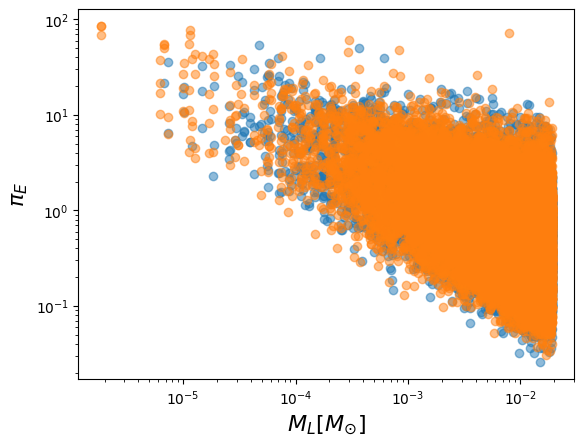

In [25]:
plt.scatter(df_selected['mass'],df_selected['piE'],alpha=0.5)
plt.scatter(df_not_selected['mass'],df_not_selected['piE'],alpha=0.5)
plt.xlabel(r'$M_L [M_{\odot}$]', fontsize=16)
plt.ylabel(r'$\pi_E $', fontsize=16)
plt.yscale('log')
plt.xscale('log')
plt.show()

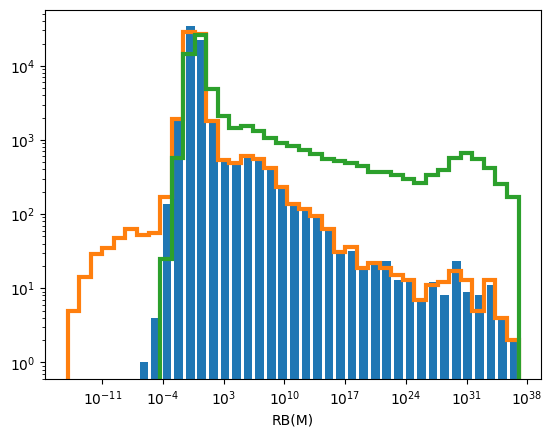

In [26]:
plt.hist(met_1_rr['mass_v1'],np.logspace(-15,37,40),rwidth=0.9)
plt.hist(met_1_rr['mass_v2'],np.logspace(-15,37,40),histtype='step',linewidth=3)
if not model == "PSPL":
    plt.hist(met_1_rr['mass_v3'],np.logspace(-15,37,40),histtype='step',linewidth=3)
plt.yscale("log")
plt.xscale("log")
plt.xlabel("RB(M)")
plt.show()